# Bank Customer Churn Prediction

## Data Understanding

### Objective

The objective of the following code is to explore the banking customer churn dataset, understand its structure, identify data quality issues, and gain an initial understanding of the variables before data preprocessing and model development.

In [483]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")



## Load the Dataset


In [484]:
from pathlib import Path


DATA_PATH = Path("C:/Users/nount/OneDrive/Desktop/Six months Bootcamp 18 October 2025/00 MBA/0 Data science 5000/Bank-Customer-Churn-Prediction/data/raw")

df = pd.read_csv(DATA_PATH / "Banking_Churn.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Observations

The first five rows confirm that the dataset has been loaded successfully.
Each row represents one customer, while each column represents a customer attribute such as age, balance, or tenure.

## Dataset Overview

Before performing any analysis or preprocessing, it is important to understand the structure of the dataset. This includes the number of observations, variables, data types, and whether any missing values are present. This initial inspection helps identify potential data quality issues and guides the preprocessing stage.

In [485]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


### Observations

The dataset contains **10,000 customer records** and **12 variables**, including customer demographic, financial, and banking information. There are **no missing values**, indicating that the dataset is complete and ready for further analysis. The variables consist of **8 integer**, **2 floating-point**, and **2 categorical (string)** features. The target variable is **`churn`**, which indicates whether a customer has left the bank.

## Dataset Dimensions

The next step is to examine the dimensions of the dataset. Understanding the number of observations and variables helps determine whether the dataset is suitable for machine learning analysis.

In [486]:
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 10000
Number of columns: 12


### Observations

The dataset contains **10,000 observations** and **12 variables**. The number of observations is sufficient for training and evaluating machine learning classification models. The variables represent customer characteristics that may influence the likelihood of customer churn.

## Variable Names

Before analyzing the data, it is important to identify the available variables and understand what each one represents. This helps determine which variables may be useful predictors of customer churn and which variables may require preprocessing.

In [487]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

### Observations

The dataset contains customer demographic, financial, and banking relationship variables. The target variable is **`churn`**, while **`customer_id`** uniquely identifies each customer and is not expected to contribute to predicting customer churn. It will likely be removed before model training because it does not contain predictive information.

## Variable Classification

Before building machine learning models, it is important to classify each variable according to its data type and role in the analysis. This helps determine how each variable should be preprocessed and whether it should be included in the predictive model.

In [488]:
df.dtypes

customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

### Observations

The dataset contains a mixture of numerical, categorical, binary, and identifier variables. The numerical variables describe customer characteristics such as age, credit score, balance, and estimated salary. The categorical variables include country and gender, while credit card ownership and active membership are binary variables represented as 0 and 1. The variable `customer_id` is an identifier and will not be used for model training because it does not provide predictive information. The target variable is `churn`, which indicates whether a customer left the bank.

## Target Variable Distribution

The first step in a classification problem is to understand the distribution of the target variable. This analysis shows how many customers stayed with the bank and how many customers churned. It also helps determine whether the dataset is balanced or imbalanced, which may influence model performance and evaluation.

In [489]:

df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

### Business Insight

Although approximately 80% of customers remained with the bank, this does not mean that a model predicting every customer will stay would be useful. Such a model would achieve nearly 80% accuracy while failing to identify any customers at risk of churning. Therefore, accuracy alone is not an appropriate performance measure for this project, and additional metrics such as precision, recall, F1-score, and ROC-AUC will also be considered.

## Visualizing the Target Variable

A graphical representation of the target variable provides a clearer understanding of the proportion of customers who stayed and those who churned. Visualizations make it easier to identify class imbalance and communicate findings to both technical and non-technical audiences.

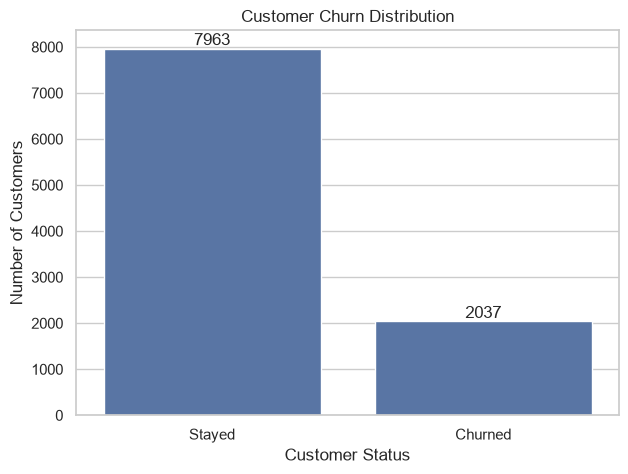

In [490]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="churn")

ax.set_xticklabels(["Stayed", "Churned"])

# Add the counts above each bar
for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

### Observations

The bar chart confirms that substantially more customers remained with the bank than churned. Approximately 80% of customers stayed, while about 20% left the bank. This visual evidence confirms that the dataset is imbalanced, meaning the majority class is considerably larger than the minority class. As a result, relying solely on accuracy to evaluate machine learning models could be misleading, making additional evaluation metrics such as recall, precision, F1-score, and ROC-AUC essential.

# Relationship Between Age and Customer Churn

Age is one of the most important demographic variables in banking. In this section, we examine whether customer age is associated with churn by comparing the age distributions of customers who stayed with those who left the bank.

In [369]:
df.groupby("churn")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


### Observations

Customers who churned have a noticeably higher average age (44.8 years) than customers who remained with the bank (37.4 years). The median age also differs substantially (45 versus 36 years), suggesting that older customers are more likely to leave the bank. This finding contradicts the initial hypothesis that younger customers would be more likely to churn, highlighting the importance of validating assumptions with data rather than relying solely on intuition. The similar mean and median values within each group indicate that the age distributions are reasonably symmetric.

## Age Distribution by Customer Churn

While summary statistics provide useful numerical information, they do not reveal the full distribution of customer ages. A boxplot allows us to compare the age distributions of customers who stayed and those who churned, helping identify differences in central tendency, variability, and potential outliers.

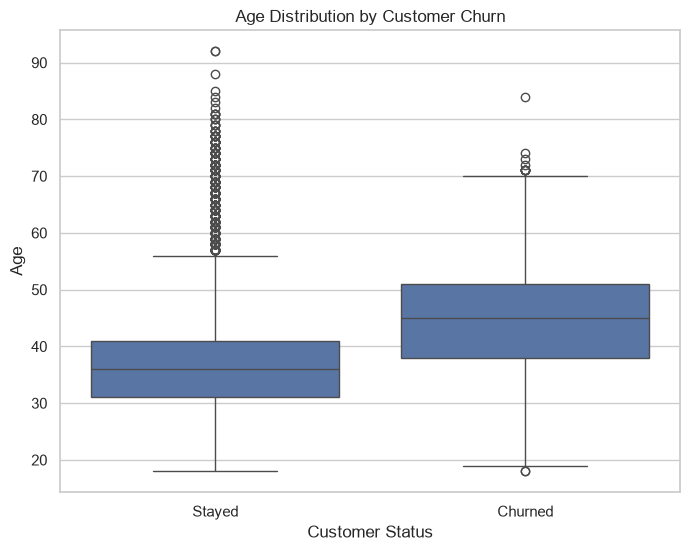

In [370]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="churn",
    y="age"
)

plt.xticks([0,1],["Stayed","Churned"])

plt.title("Age Distribution by Customer Churn")

plt.xlabel("Customer Status")

plt.ylabel("Age")

plt.show()

## Selecting Numerical Variables

Before automating the exploratory data analysis, we first identify the numerical variables that will be examined. Automating repetitive analyses improves efficiency and allows us to focus on interpreting business insights rather than writing repetitive code.

In [371]:
numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

numerical_columns

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'estimated_salary']

In [372]:
for column in numerical_columns:

    print("=" * 60)
    print(f"Summary Statistics for: {column}")
    print("=" * 60)

    display(df.groupby("churn")[column].describe())

    print("\n")

Summary Statistics for: credit_score


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,651.853196,95.653837,405.0,585.0,653.0,718.0,850.0
1,2037.0,645.351497,100.321503,350.0,578.0,646.0,716.0,850.0




Summary Statistics for: age


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0




Summary Statistics for: tenure


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,5.033279,2.880658,0.0,3.0,5.0,7.0,10.0
1,2037.0,4.932744,2.936106,0.0,2.0,5.0,8.0,10.0




Summary Statistics for: balance


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09




Summary Statistics for: products_number


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,1.544267,0.509536,1.0,1.0,2.0,2.0,3.0
1,2037.0,1.475209,0.801521,1.0,1.0,1.0,2.0,4.0




Summary Statistics for: estimated_salary


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,99738.391772,57405.586966,90.07,50783.49,99645.04,148609.955,199992.48
1,2037.0,101465.677531,57912.418071,11.58,51907.72,102460.84,152422.910,199808.10


## Creating a Reusable Visualization Function

Instead of writing separate code for every numerical variable, we create a reusable Python function. This follows good programming practices by reducing repetition and making the code easier to maintain. The function can generate the same visualization for any numerical feature in the dataset.

In [373]:
def plot_boxplot(variable):

    plt.figure(figsize=(8,6))

    sns.boxplot(
        data=df,
        x="churn",
        y=variable
    )

    plt.xticks([0,1],["Stayed","Churned"])

    plt.title(f"{variable.replace('_',' ').title()} by Customer Status")

    plt.xlabel("Customer Status")

    plt.ylabel(variable.replace("_"," ").title())

    plt.show()

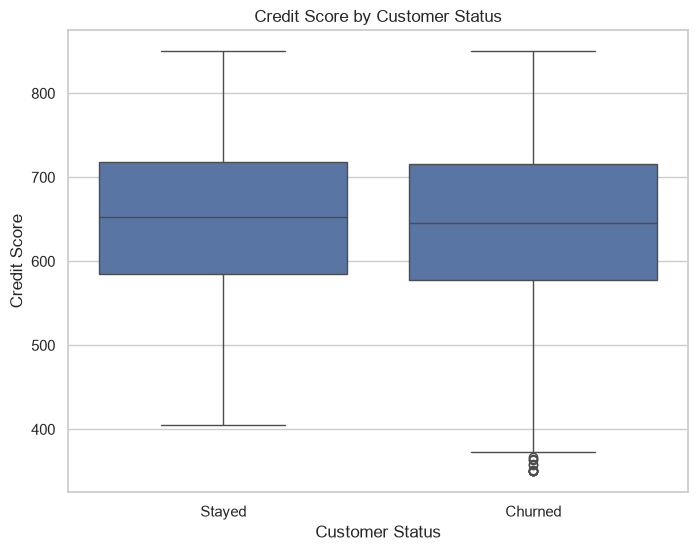

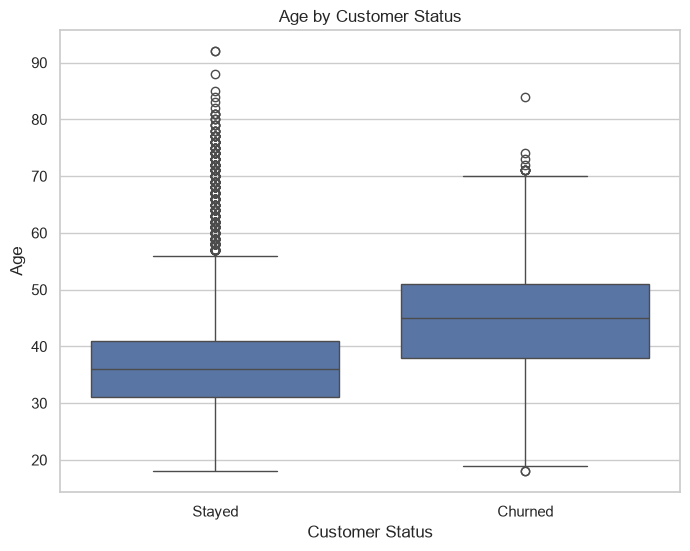

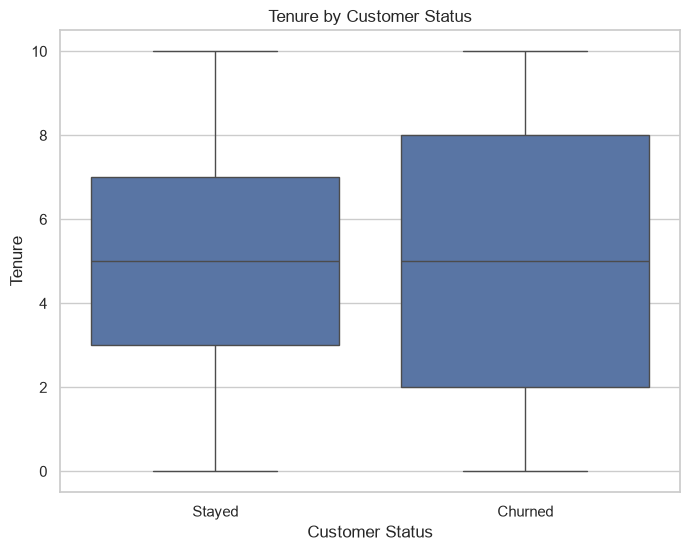

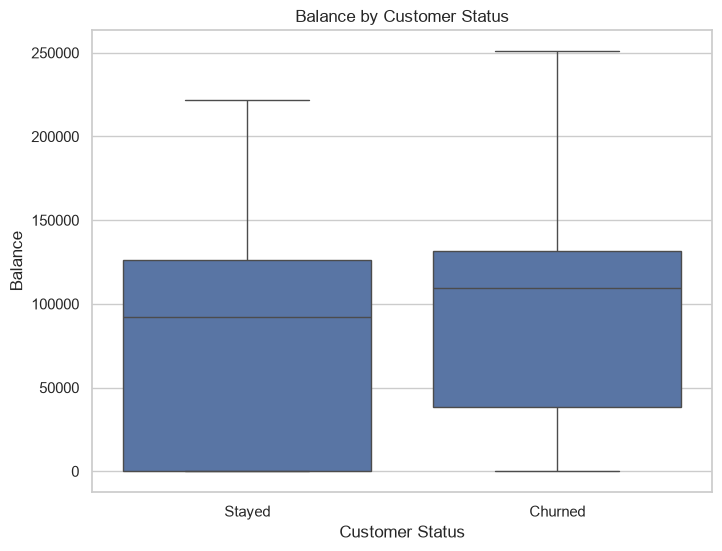

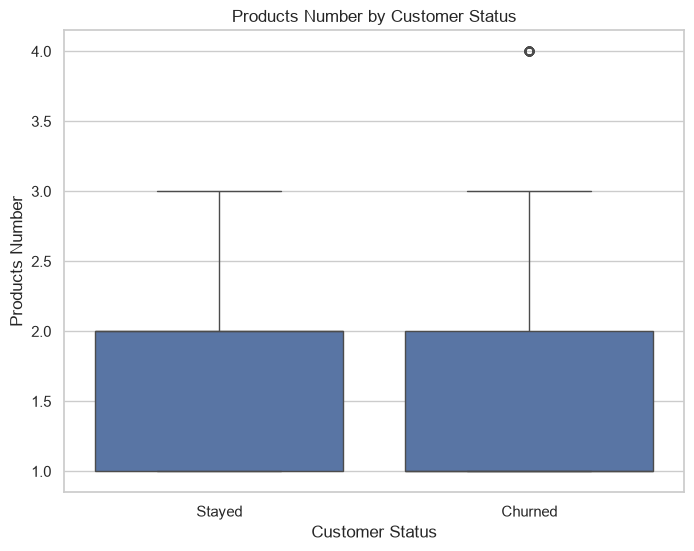

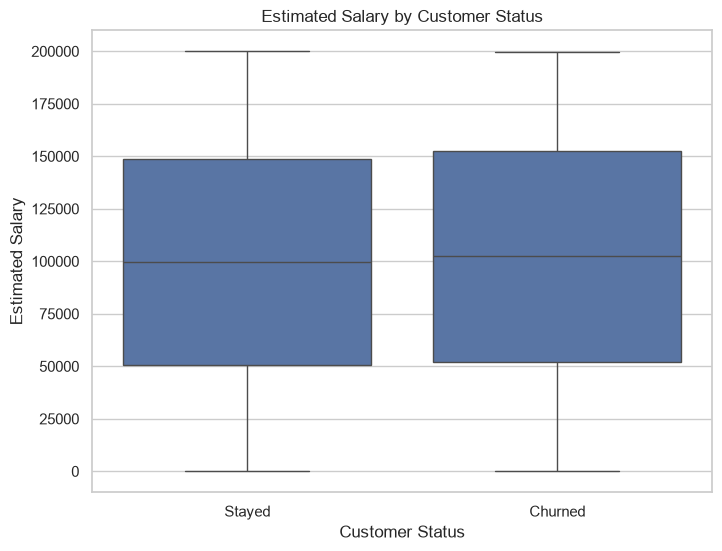

In [374]:
for column in numerical_columns:

    plot_boxplot(column)

# Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. Understanding these relationships helps identify variables that may contain similar information, reveal important customer characteristics, and support feature selection before building machine learning models.

In [375]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


### Why Correlation Matters

Correlation helps identify relationships between numerical variables by measuring how strongly they move together. Strong correlations can reveal useful patterns, identify redundant variables, and support feature selection. However, correlation does not imply causation. A strong correlation indicates an association between variables but does not prove that one variable causes changes in the other. Business context and domain knowledge remain essential when interpreting correlation results.

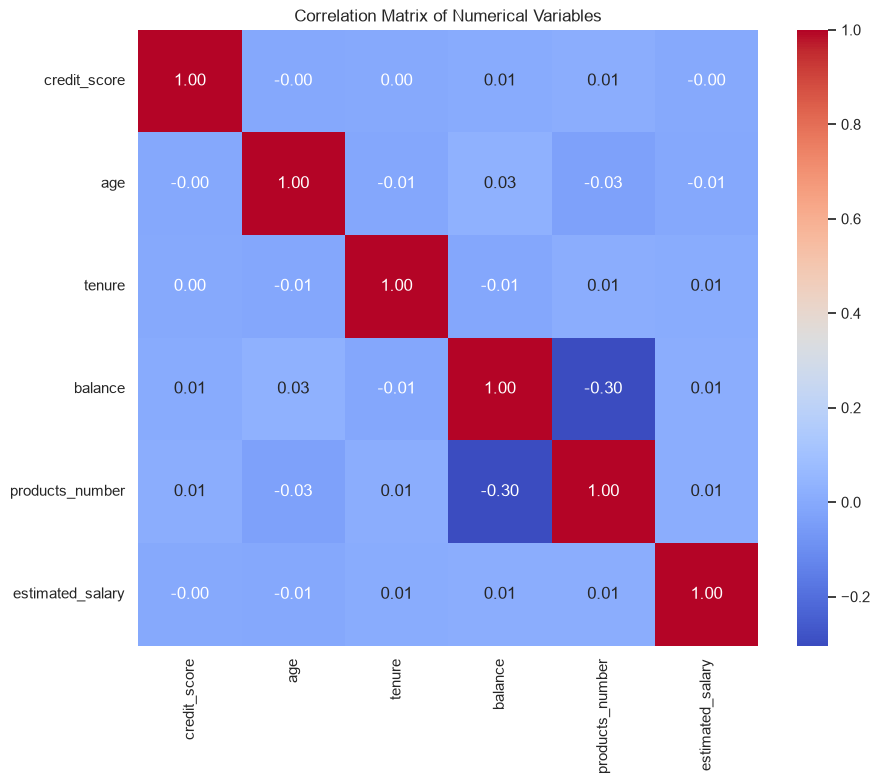

In [376]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

# Customer Activity and Churn

Customer activity may be an important indicator of customer engagement. In this section, we examine whether active members are less likely to churn than inactive members by comparing churn rates across the two groups.

In [377]:
df.groupby("active_member")["churn"].mean()

active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64

In [378]:
churn_rate = (
    df.groupby("active_member")["churn"]
      .mean()
      .reset_index()
)

churn_rate

,active_member,churn
0,0,0.268509
1,1,0.142691


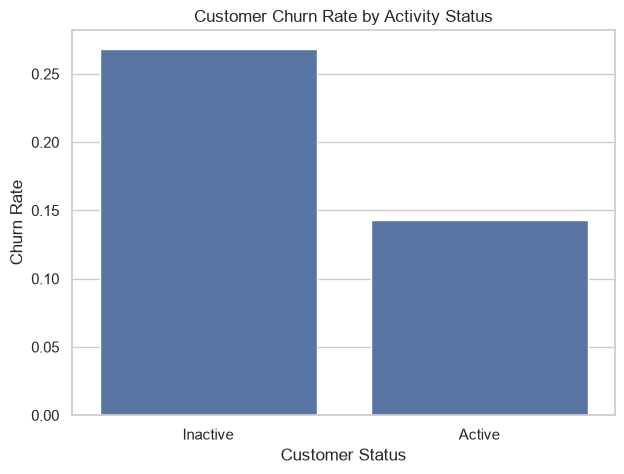

In [379]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_rate,
    x="active_member",
    y="churn"
)

ax.set_xticklabels(["Inactive","Active"])

plt.title("Customer Churn Rate by Activity Status")

plt.xlabel("Customer Status")

plt.ylabel("Churn Rate")

plt.show()

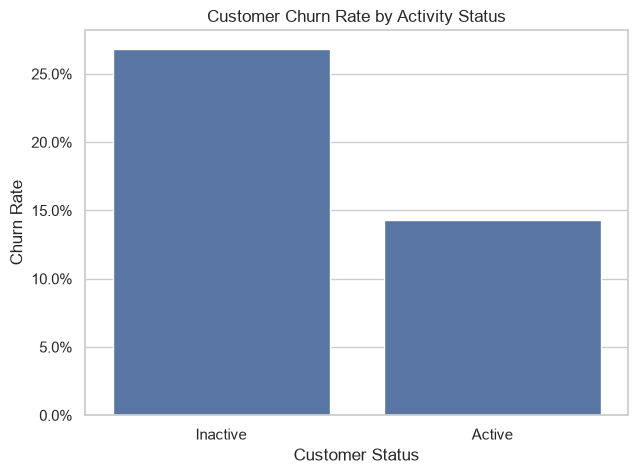

In [380]:
import matplotlib.ticker as mtick

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_rate,
    x="active_member",
    y="churn"
)

ax.set_xticklabels(["Inactive","Active"])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Customer Churn Rate by Activity Status")

plt.xlabel("Customer Status")

plt.ylabel("Churn Rate")

plt.show()

In [381]:
categorical_columns = [
    "gender",
    "country",
    "active_member",
    "credit_card"
]

categorical_columns

['gender', 'country', 'active_member', 'credit_card']

In [382]:
def plot_churn_rate(variable):

    churn_rate = (
        df.groupby(variable)["churn"]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=churn_rate,
        x=variable,
        y="churn"
    )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.title(f"Churn Rate by {variable.replace('_',' ').title()}")

    plt.xlabel(variable.replace("_"," ").title())

    plt.ylabel("Churn Rate")

    plt.show()


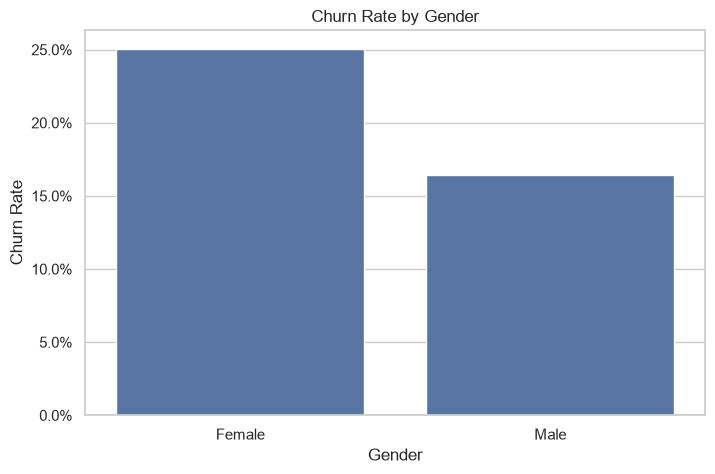

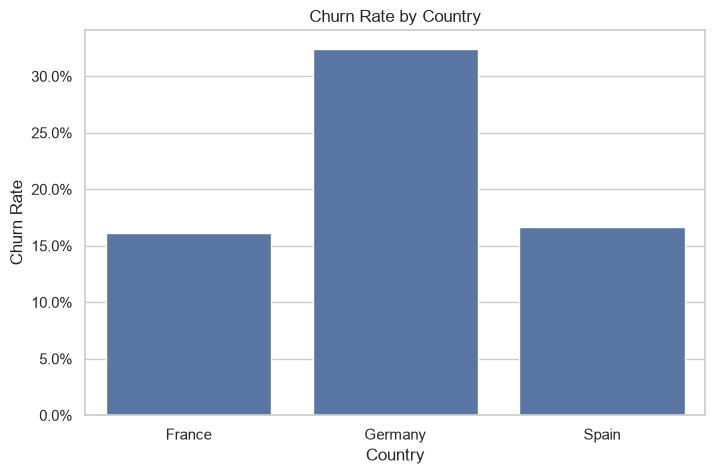

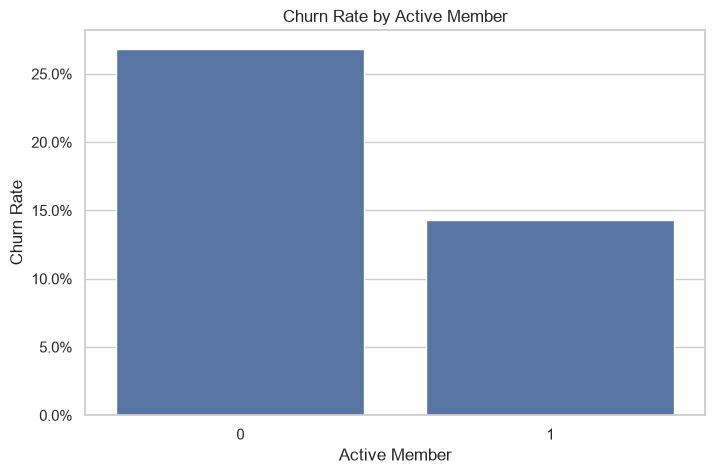

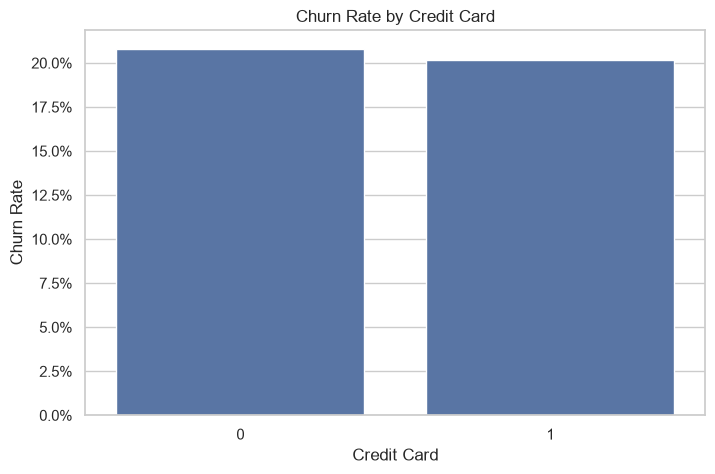

In [383]:
for column in categorical_columns:

    plot_churn_rate(column)

# Train-Test Split

To evaluate how well the machine learning model generalizes to unseen customers, the dataset is divided into a training set and a testing set. The model will learn patterns from the training data and will be evaluated on customers it has never seen before.

In [384]:
from sklearn.model_selection import train_test_split

# Separate the Features and Target Variable

Before training a machine learning model, the dataset must be divided into two parts:

- **Features (X):** The independent variables that the model will use to learn patterns.
- **Target (y):** The dependent variable that the model will predict.

The `customer_id` column is removed because it is only an identifier and does not contain useful information for predicting customer churn. The `churn` column is stored separately as the target variable.

In [385]:
X = df.drop(columns=["customer_id", "churn"])

y = df["churn"]

# Encode the Country Variable

Machine learning algorithms require numerical input and cannot directly process text values such as country names.

The `country` variable contains three categories (France, Germany, and Spain), which have no natural order. Therefore, One-Hot Encoding is applied to create separate binary columns for each country.

The parameter `drop_first=True` removes one of the encoded columns to avoid redundant information because the omitted country can always be inferred from the remaining dummy variables.

In [386]:
X = pd.get_dummies(
    X,
    columns=["country"],
    drop_first=True,
    dtype=int
)

# Encode the Gender Variable

The `gender` variable contains only two categories (Male and Female). Since it is a binary categorical variable, it can be efficiently represented using a single numerical column.

Male is encoded as 0 and Female as 1. This preserves all available information while using only one feature.

In [387]:
X["gender"] = X["gender"].map({
    "Male": 0,
    "Female": 1
})

# Inspect the Preprocessed Dataset

After encoding the categorical variables, the feature matrix is now fully numerical and suitable for machine learning algorithms such as Logistic Regression.

Displaying the first few observations allows us to verify that the preprocessing steps were applied correctly before proceeding to model training.

In [388]:
X.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,1


# Summary

The preprocessing stage is now complete.

The feature matrix (`X`) contains only numerical variables, while the target variable (`y`) stores the customer churn labels. The dataset is now ready for feature scaling and model training.

# Scale the Numerical Features

The numerical variables in the dataset have very different ranges.

For example:

- age may range from approximately 18 to 90.
- balance may exceed 200,000.
- estimated_salary may also contain very large values.
- Binary variables such as active_member contain only 0 and 1.

Logistic Regression is sensitive to differences in feature scale because it estimates coefficients using numerical optimization. Features with much larger numerical ranges can influence the optimization process more strongly and may slow model training.

Feature scaling transforms the numerical variables into comparable ranges without changing their underlying relationships.

The `StandardScaler` class is imported from Scikit-learn.

StandardScaler transforms each selected numerical variable so that it has approximately:

- A mean of 0
- A standard deviation of 1

This process is called standardization.

In [389]:
from sklearn.preprocessing import StandardScaler

A list is created containing the continuous numerical features that require standardization.

Binary variables and One-Hot Encoded variables are excluded because they already use a consistent 0–1 representation.

In [390]:
numerical_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

The dataset is divided into training and testing subsets.

The training data will be used to train the model, while the testing data will be reserved for evaluating how well the model performs on unseen customers.

An 80/20 split is used, meaning 80% of the observations are assigned to training and 20% are assigned to testing.

The `random_state` parameter ensures that the same split can be reproduced each time the notebook is executed.

In [391]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

The data has now been divided into four objects:

- X_train: Features used to train the model
- X_test: Features used to test the model
- y_train: Correct churn labels for the training observations
- y_test: Correct churn labels for the testing observations

The training and testing features remain aligned with their corresponding target values.

In [392]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


# Standardize the Numerical Features

The `StandardScaler` is fitted using only the training data.

During this step, the scaler calculates the mean and standard deviation for each numerical feature in the training dataset.

These statistics are then used to standardize both the training and testing datasets.

Fitting the scaler only on the training data prevents data leakage because the testing data remains completely unseen during model training.

In [393]:
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

# Verify the Standardized Features

Display the first few observations of the standardized training dataset to verify that the transformation was successfully applied.

The numerical features should now have values centered approximately around zero, while the binary variables remain unchanged.

In [394]:
X_train.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain
9254,0.356500,0,-0.655786,0.345680,-1.218471,0.808436,1,1,1.367670,0,0
1561,-0.203898,0,0.294938,-0.348369,0.696838,0.808436,1,1,1.661254,1,0
1670,-0.961472,0,-1.416365,-0.695393,0.618629,-0.916688,1,0,-0.252807,0,1
6087,-0.940717,1,-1.131148,1.386753,0.953212,-0.916688,1,0,0.915393,0,0
6669,-1.397337,0,1.625953,1.386753,1.057449,-0.916688,0,0,-1.059600,0,0


# Train the Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

The model learns the relationship between the input features and the target variable by estimating the probability that each customer belongs to the churn class.

The model is trained using only the training dataset.

In [395]:
from sklearn.linear_model import LogisticRegression

In [396]:
model = LogisticRegression(random_state=42)

Create an instance of the Logistic Regression model.

The `random_state` parameter is specified to ensure reproducibility whenever randomness is involved during optimization.

# Train the Logistic Regression Model

The Logistic Regression model is trained using the training dataset.

During training, the algorithm learns the relationship between the predictor variables (X) and the target variable (y). It estimates a set of coefficients that best describe how the input features collectively influence the probability of customer churn.

Once training is complete, the model can be used to predict the churn probability of new customers that were not included in the training dataset.

In [397]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

# Model Training Completed

The Logistic Regression model has now been trained.

The model has learned patterns from the training data and is ready to make predictions on previously unseen customers in the testing dataset.

# Predict Customer Churn

The trained Logistic Regression model is applied to the testing dataset.

For each customer in the testing set, the model predicts whether the customer is likely to churn (1) or remain with the bank (0).

These predictions will be compared with the actual outcomes to evaluate the model's performance.

In [398]:
y_pred = model.predict(X_test)

# Inspect the First Predictions

Display the first twenty predicted churn values produced by the Logistic Regression model.

In [399]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0])

# Predict Customer Churn Probabilities

In addition to predicting the final class (0 or 1), Logistic Regression estimates the probability that each customer belongs to each class.

The first probability corresponds to the likelihood that the customer will remain with the bank (Class 0), while the second probability represents the likelihood that the customer will churn (Class 1).

These probabilities provide more information than the final prediction and can support business decisions such as identifying high-risk customers for retention campaigns.

In [400]:
y_prob = model.predict_proba(X_test)

# Display the Predicted Probabilities

Display the predicted probabilities for the first five customers in the testing dataset.

Each row contains two probabilities:

- Column 1: Probability of staying (Class 0)
- Column 2: Probability of churning (Class 1)

The probabilities in each row sum to 1.

In [401]:
y_prob[:20]

array([[0.76747828, 0.23252172],
       [0.92253367, 0.07746633],
       [0.68486362, 0.31513638],
       [0.56525498, 0.43474502],
       [0.93283894, 0.06716106],
       [0.95427906, 0.04572094],
       [0.73886349, 0.26113651],
       [0.78979462, 0.21020538],
       [0.67488958, 0.32511042],
       [0.69659811, 0.30340189],
       [0.74274498, 0.25725502],
       [0.47650698, 0.52349302],
       [0.77641554, 0.22358446],
       [0.45177933, 0.54822067],
       [0.98010761, 0.01989239],
       [0.73793013, 0.26206987],
       [0.70564016, 0.29435984],
       [0.8078338 , 0.1921662 ],
       [0.91702929, 0.08297071],
       [0.7990348 , 0.2009652 ]])

# Evaluate Model Accuracy

Accuracy measures the proportion of predictions that were classified correctly.

It is calculated as the number of correct predictions divided by the total number of predictions.

Although accuracy is easy to understand, it should not be used alone for imbalanced classification problems because it does not distinguish between different types of prediction errors.

In [402]:
from sklearn.metrics import accuracy_score

In [403]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8115


The Logistic Regression model correctly classified approximately 81.15% of the customers in the testing dataset.

While this appears to indicate good performance, accuracy alone does not reveal whether the model correctly identifies customers who actually churn. Additional evaluation metrics are therefore required.

# Evaluate the Confusion Matrix

Although Accuracy, Precision, Recall, and F1-score summarize the model's performance, they do not show the exact number of correct and incorrect predictions.

The confusion matrix provides a detailed summary of the model's predictions by comparing the predicted classes with the actual customer outcomes.

This visualization helps identify:

- True Positives (Correctly predicted churn)
- True Negatives (Correctly predicted non-churn)
- False Positives (Customers incorrectly predicted to churn)
- False Negatives (Customers incorrectly predicted to stay)

The confusion matrix serves as the foundation for all classification evaluation metrics.

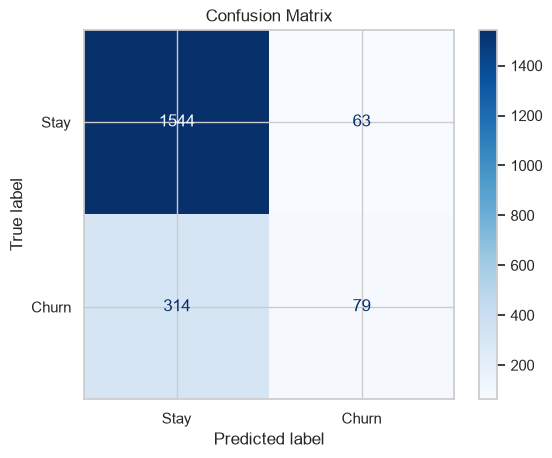

In [404]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Interpret the Confusion Matrix

The confusion matrix summarizes the model's predictions into four categories:

- True Negatives (TN): Customers correctly predicted to remain.
- False Positives (FP): Customers incorrectly predicted to churn.
- False Negatives (FN): Customers incorrectly predicted to remain.
- True Positives (TP): Customers correctly predicted to churn.

From a banking perspective, False Negatives are particularly costly because they represent customers who actually leave without receiving any retention intervention.

False Positives increase marketing costs because retention resources are allocated to customers who were unlikely to churn.

In [405]:
print(cm)

[[1544   63]
 [ 314   79]]


# Generate the Classification Report

The classification report combines several evaluation metrics into a single summary.

It reports:

- Precision
- Recall
- F1-score
- Support (number of observations)

for each class separately, as well as overall averages.

This report provides a comprehensive evaluation of the Logistic Regression model.

In [406]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



# Evaluate the Model Using the ROC Curve

While Accuracy, Precision, Recall, and F1-score evaluate the model using a fixed classification threshold (typically 0.5), the Receiver Operating Characteristic (ROC) curve evaluates the model across all possible classification thresholds.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate.

A model with good predictive performance will produce a curve that approaches the upper-left corner of the graph, indicating a high True Positive Rate and a low False Positive Rate.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to distinguish between customers who churn and those who remain. An ROC-AUC value closer to 1 indicates better discrimination.

In [407]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute the ROC Curve and AUC Score

Unlike the previous evaluation metrics, the ROC curve requires the predicted probabilities rather than the predicted classes.

The Logistic Regression model estimates the probability that each customer belongs to the churn class.

These probabilities are used to calculate the ROC curve and the corresponding Area Under the Curve (AUC).

In [408]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.7790


# Plot the ROC Curve

The ROC curve visualizes the classification performance of the Logistic Regression model across different probability thresholds.

The diagonal reference line represents a model making random predictions.

A curve that remains well above the diagonal indicates that the model has learned meaningful patterns from the data.

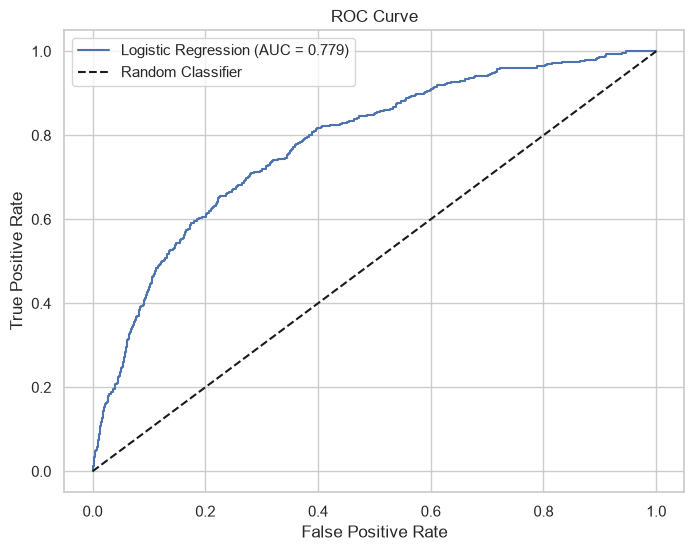

In [409]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot([0,1],[0,1],'k--',label="Random Classifier")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Interpret the Logistic Regression Coefficients

One advantage of Logistic Regression is that it produces a coefficient for each predictor variable.

Each coefficient describes the relationship between a feature and the probability of customer churn while holding all other variables constant.

The interpretation is as follows:

- A **positive coefficient** indicates that an increase in the feature is associated with a higher probability of customer churn.
- A **negative coefficient** indicates that an increase in the feature is associated with a lower probability of customer churn.
- A coefficient close to zero suggests that the feature has little influence on churn.

Although the coefficient magnitude provides useful information, it should only be compared between standardized numerical variables because they are measured on the same scale.

In [410]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,credit_score,-0.067692
1,gender,0.530122
2,age,0.753848
3,tenure,-0.042592
4,balance,0.161192
5,products_number,-0.060530
6,credit_card,-0.022682
7,active_member,-1.063399
8,estimated_salary,0.015775
9,country_Germany,0.775134


# Sort the Model Coefficients

Sorting the coefficients makes it easier to identify which variables have the strongest positive and negative relationships with customer churn.

The variables with the largest positive coefficients are associated with increased churn risk, whereas those with the largest negative coefficients are associated with customer retention.

In [411]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
9,country_Germany,0.775134
2,age,0.753848
1,gender,0.530122
4,balance,0.161192
10,country_Spain,0.088847
8,estimated_salary,0.015775
6,credit_card,-0.022682
3,tenure,-0.042592
5,products_number,-0.060530
0,credit_score,-0.067692


# Visualize the Logistic Regression Coefficients

A horizontal bar chart is used to visualize the magnitude and direction of the Logistic Regression coefficients.

Variables with positive coefficients increase the likelihood of customer churn, while variables with negative coefficients decrease the likelihood of churn.

This visualization provides an intuitive overview of the relative influence of each predictor.

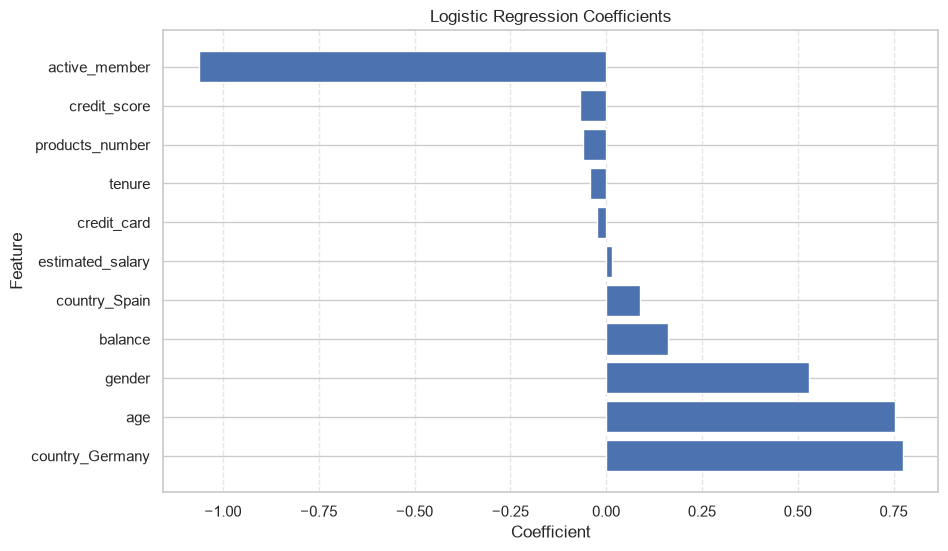

In [412]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.title("Logistic Regression Coefficients")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Interpret the Logistic Regression Results

The coefficient plot provides insight into the factors associated with customer churn.

Variables with large positive coefficients contribute to an increased probability of churn, whereas variables with large negative coefficients contribute to customer retention.

These findings can help bank managers identify customer characteristics associated with higher churn risk and design targeted retention strategies.

Because the numerical variables were standardized before model training, the coefficient magnitudes can be meaningfully compared across numerical features. However, coefficient magnitude alone should not be interpreted as a definitive measure of feature importance, especially when predictor variables are correlated.

# Applying SMOTE After Establishing a Baseline Model

Before applying the Synthetic Minority Over-sampling Technique (SMOTE), the Logistic Regression model was intentionally trained and evaluated using the original imbalanced dataset.

This baseline model provides a reference point for assessing the impact of class imbalance on predictive performance. Establishing a baseline allows the performance obtained from the original dataset to be directly compared with the performance achieved after balancing the training data using SMOTE.

After this comparison, the balanced training dataset will be used consistently for all subsequent machine learning models, including Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost. This ensures that all models are trained and evaluated under the same preprocessing pipeline, enabling a fair and meaningful comparison of their predictive performance.

# Address Class Imbalance Using SMOTE

The target variable is imbalanced, with approximately 80% of customers remaining with the bank and only 20% churning.

Machine learning models trained on imbalanced data may become biased toward the majority class, resulting in high overall accuracy but poor detection of customers who are likely to churn.

To reduce this bias, the Synthetic Minority Over-sampling Technique (SMOTE) is applied to the training dataset. SMOTE generates synthetic observations for the minority class by interpolating between existing minority-class samples rather than simply duplicating them.

Importantly, SMOTE is applied only to the training data after the train-test split. The testing dataset remains unchanged to provide an unbiased evaluation of model performance on previously unseen customers.

# Import the SMOTE Library

The Synthetic Minority Over-sampling Technique (SMOTE) is implemented using the imbalanced-learn library.

SMOTE creates synthetic observations for the minority class by generating new samples between existing minority-class observations. Unlike simple oversampling, SMOTE does not duplicate existing records, reducing the likelihood of overfitting while improving class balance.

In [413]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the Training Dataset

SMOTE is applied only to the training data to balance the target classes.

The testing dataset is intentionally excluded from this process because it represents previously unseen customers. Keeping the testing data unchanged ensures that the evaluation reflects how the model would perform in a real-world banking environment.

The balanced training dataset produced by SMOTE will be used for all subsequent machine learning models developed in this project.

In [414]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Verify the Class Distribution After SMOTE

The distribution of the target variable is examined after applying SMOTE to confirm that the minority and majority classes are now balanced.

A balanced training dataset allows the machine learning algorithms to learn patterns associated with both customer retention and customer churn more effectively.

In [415]:
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

churn
0    6356
1    1644
Name: count, dtype: int64

churn
0    6356
1    6356
Name: count, dtype: int64


# Visualize the Class Distribution Before and After SMOTE

A visual comparison of the class distribution before and after applying SMOTE helps illustrate how the imbalance has been addressed.

The balanced dataset produced by SMOTE will be used to train the remaining machine learning models and to retrain the Logistic Regression model for comparison with the baseline results.

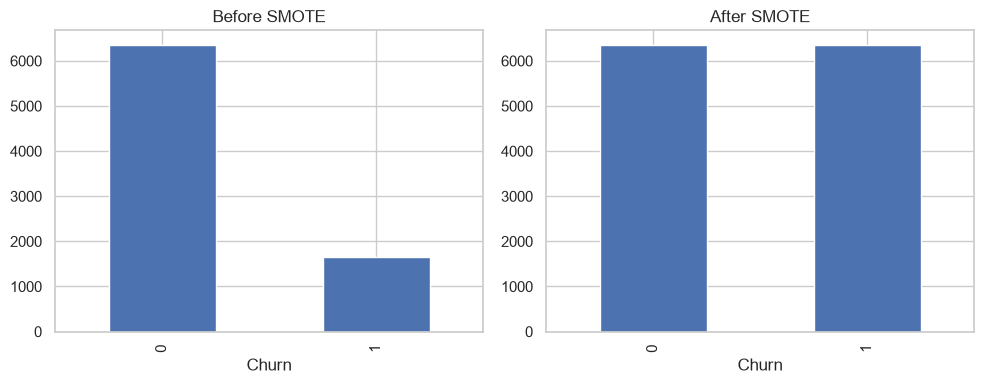

In [416]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(
    kind="bar",
    ax=axes[0],
    title="Before SMOTE"
)

y_train_smote.value_counts().plot(
    kind="bar",
    ax=axes[1],
    title="After SMOTE"
)

axes[0].set_xlabel("Churn")
axes[1].set_xlabel("Churn")

plt.tight_layout()

plt.show()

# Retrain the Logistic Regression Model Using the Balanced Training Dataset

After balancing the training data with SMOTE, the Logistic Regression model is retrained using the synthetic training dataset.

Training the model on the balanced dataset allows it to learn the characteristics of both customer classes more effectively, particularly the minority class representing customers who churn.

The resulting model will be compared with the baseline Logistic Regression model to evaluate whether balancing the training data improves predictive performance.

In [417]:
from sklearn.linear_model import LogisticRegression

model_smote = LogisticRegression(
    random_state=42
)

model_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

# Predict Customer Churn Using the SMOTE Model

The retrained Logistic Regression model is applied to the original testing dataset.

Although the model was trained using the balanced dataset, predictions are generated on the untouched testing data to simulate real-world customer behavior and provide an unbiased evaluation.

In [418]:
y_pred_smote = model_smote.predict(X_test)

y_prob_smote = model_smote.predict_proba(X_test)[:,1]

# Evaluate the SMOTE Logistic Regression Model

The performance of the Logistic Regression model trained with SMOTE is evaluated using the same metrics as the baseline model.

Using identical evaluation metrics allows a fair comparison between the original and balanced training approaches.

In [419]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

precision_smote = precision_score(
    y_test,
    y_pred_smote
)

recall_smote = recall_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

# Display the Performance Metrics

The evaluation metrics obtained from the Logistic Regression model trained with SMOTE are displayed below.

These results will later be compared with the baseline Logistic Regression model to assess the impact of balancing the training data.

In [420]:
print(f"Accuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1-score : {f1_smote:.4f}")
print(f"ROC-AUC  : {auc_smote:.4f}")

Accuracy : 0.7125
Precision: 0.3767
Recall   : 0.7074
F1-score : 0.4916
ROC-AUC  : 0.7764


In [421]:
baseline_accuracy = accuracy_score(y_test, y_pred)

baseline_precision = precision_score(y_test, y_pred)

baseline_recall = recall_score(y_test, y_pred)

baseline_f1 = f1_score(y_test, y_pred)

baseline_auc = roc_auc_score(y_test, y_prob)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc
    ],
    "SMOTE": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        auc_smote
    ]
})

comparison

,Metric,Baseline,SMOTE
0,Accuracy,0.811500,0.712500
1,Precision,0.556338,0.376694
2,Recall,0.201018,0.707379
3,F1-score,0.295327,0.491600
4,ROC-AUC,0.778989,0.776416


In [422]:
comparison["Improvement"] = (
    comparison["SMOTE"] - comparison["Baseline"]
)

comparison

,Metric,Baseline,SMOTE,Improvement
0,Accuracy,0.811500,0.712500,-0.099000
1,Precision,0.556338,0.376694,-0.179644
2,Recall,0.201018,0.707379,0.506361
3,F1-score,0.295327,0.491600,0.196273
4,ROC-AUC,0.778989,0.776416,-0.002573


# Interpretation of the SMOTE Results

The comparison between the baseline Logistic Regression model and the SMOTE-enhanced model demonstrates the impact of addressing class imbalance.

Although the baseline model achieved a higher overall accuracy, it identified only 20% of customers who actually churned, limiting its usefulness for customer retention. After applying SMOTE, the model's Recall increased to approximately 71%, indicating a substantial improvement in its ability to detect customers at risk of leaving.

This improvement was accompanied by a reduction in Precision and Accuracy, reflecting an increase in false positive predictions. From a business perspective, however, this trade-off may be acceptable because the cost of contacting additional customers is generally lower than the cost of losing valuable customers.

Overall, the SMOTE-enhanced Logistic Regression model provides a more effective solution for customer churn prediction because it better aligns with the project's objective of supporting proactive customer retention strategies.

# Decision Tree Classification

Decision Trees are supervised machine learning algorithms that classify observations by learning a sequence of decision rules from the training data.

Rather than estimating coefficients, a Decision Tree recursively partitions the dataset into smaller subsets by selecting the features and split points that best separate the target classes.

Each internal node represents a decision based on a feature, each branch corresponds to an outcome of that decision, and each terminal node (leaf) represents the predicted class.

Decision Trees are intuitive, easy to interpret, and capable of capturing nonlinear relationships between predictor variables and customer churn.

# Train the Decision Tree Model

The Decision Tree classifier is trained using the SMOTE-balanced training dataset.

The algorithm evaluates different predictor variables and split points to determine which decisions best separate customers who churn from those who remain with the bank.

The max_depth parameter limits the number of decision levels in the tree. Restricting tree depth helps reduce overfitting and produces a model that is easier to interpret.

In [423]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

decision_tree.fit(
    X_train_smote,
    y_train_smote
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Decision Tree Training Completed

The Decision Tree model has now learned a set of classification rules from the balanced training data.

The limited tree depth helps maintain interpretability while preventing the model from creating excessively detailed rules that may memorize the training observations.

# Predict Customer Churn Using the Decision Tree

The trained Decision Tree is applied to the original testing dataset.

The testing dataset remains unchanged and retains the real-world class distribution, allowing the model to be evaluated fairly on customers it has not previously seen.

In [424]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

# Evaluate the Decision Tree Model

The Decision Tree is evaluated using the same performance metrics used for Logistic Regression.

Using identical testing data and evaluation metrics ensures that differences in performance reflect the models themselves rather than changes in the evaluation process.

In [425]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_auc:.4f}")

Accuracy : 0.7545
Precision: 0.4255
Recall   : 0.7125
F1-score : 0.5328
ROC-AUC  : 0.8123


# Compare Logistic Regression and Decision Tree

The Decision Tree classifier was compared with the Logistic Regression model trained using the SMOTE-balanced dataset.

The Decision Tree achieved higher Accuracy, Precision, F1-score, and ROC-AUC while maintaining a similar Recall.

These results indicate that the Decision Tree provides a better balance between correctly identifying customers who churn and reducing unnecessary retention interventions.

The improved ROC-AUC further suggests that the Decision Tree has a stronger ability to distinguish between customers who are likely to churn and those who are likely to remain with the bank.

Based on these results, the Decision Tree outperformed the Logistic Regression model on this dataset.

In [426]:
comparison_models = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        auc_smote
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ]
})

comparison_models

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.712500,0.754500
1,Precision,0.376694,0.425532
2,Recall,0.707379,0.712468
3,F1-score,0.491600,0.532826
4,ROC-AUC,0.776416,0.812346


# Visualize the Decision Tree

One of the main advantages of Decision Trees is their interpretability.

Unlike many machine learning algorithms, a Decision Tree can be visualized as a flowchart that illustrates the sequence of decision rules used to classify customers.

Each internal node represents a decision based on a predictor variable, each branch corresponds to the outcome of that decision, and each terminal node (leaf) represents the predicted customer class.

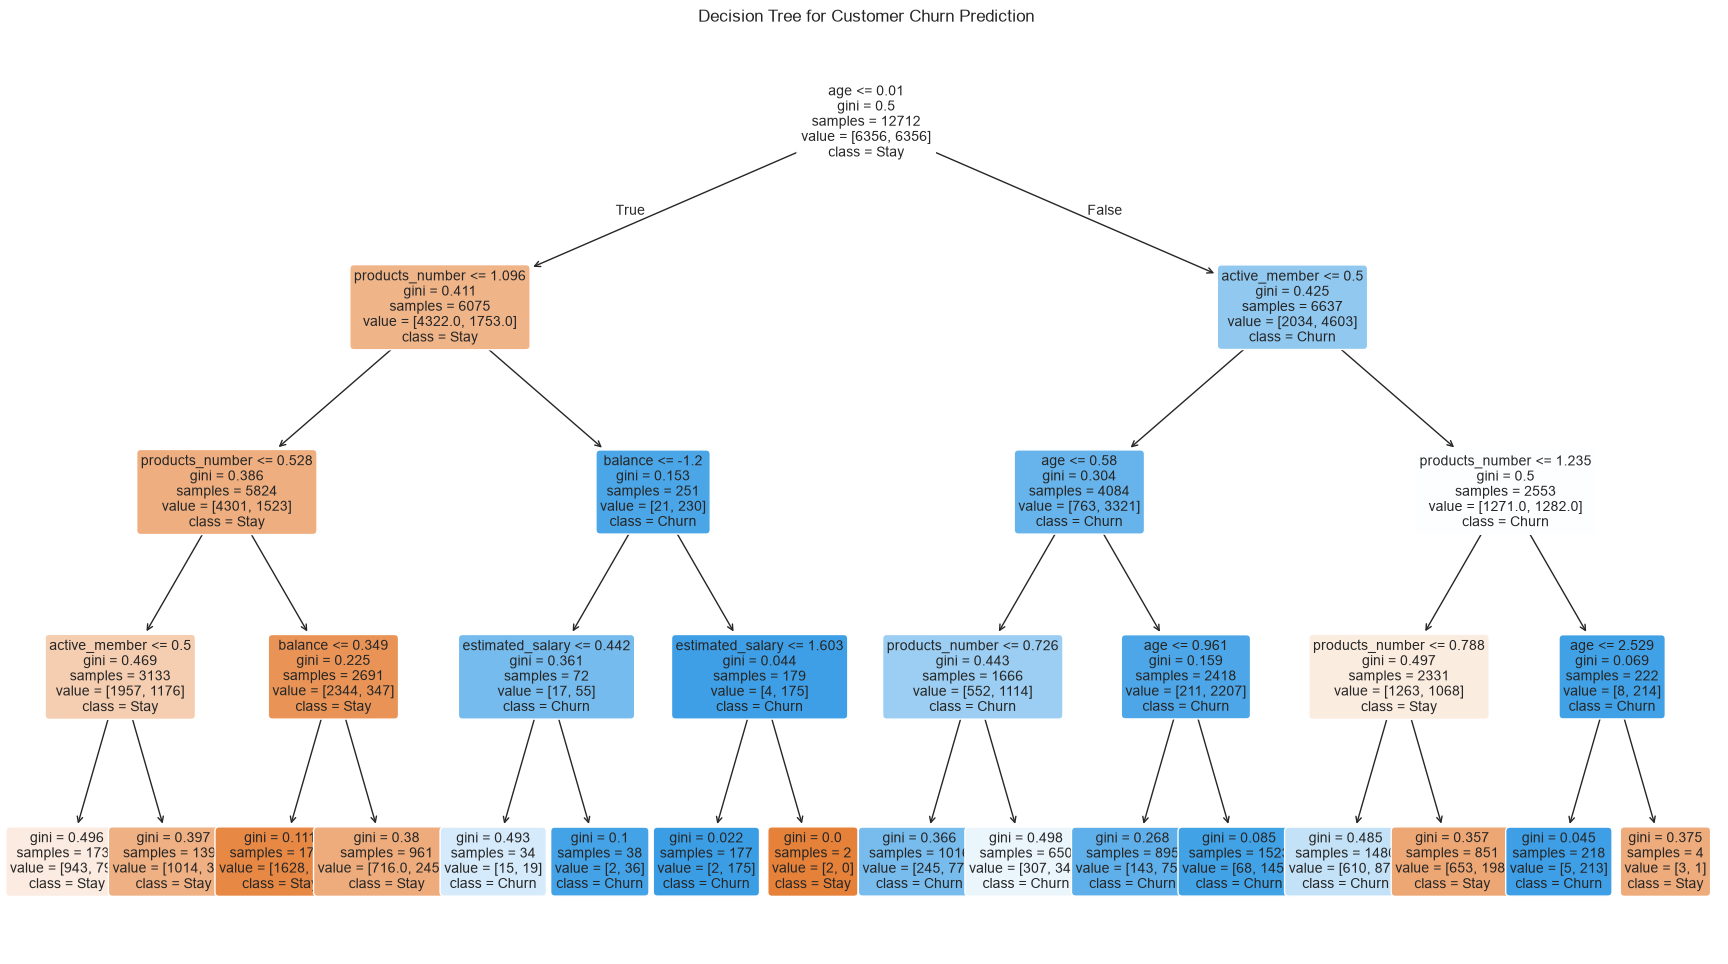

In [427]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,12))

plot_tree(
    decision_tree,
    feature_names=X_train.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Customer Churn Prediction")

plt.show()

# Interpretation of the Root Node

The root node of the Decision Tree uses the standardized age variable as the first decision rule.

Because the numerical features were standardized before model training, the split value shown in the tree does not represent the customer's age in years. Instead, it represents the standardized value produced by the StandardScaler transformation.

The fact that age appears at the root node indicates that it provides the greatest reduction in node impurity among all available predictors, making it the most informative first split for distinguishing customers who churn from those who remain with the bank.

# Measure Feature Importance

Decision Trees estimate the relative importance of each predictor by measuring how much each feature contributes to reducing node impurity throughout the tree.

Features with higher importance values contribute more to the model's classification decisions, whereas features with importance values close to zero have little influence on the predictions.

The importance values are normalized so that they sum to one.

In [428]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,age,0.520807
5,products_number,0.294055
7,active_member,0.157954
4,balance,0.023077
8,estimated_salary,0.004108
1,gender,0.000000
0,credit_score,0.000000
6,credit_card,0.000000
3,tenure,0.000000
9,country_Germany,0.000000


# Visualize Feature Importance

A horizontal bar chart is used to compare the relative importance of each predictor in the Decision Tree model.

Features with larger importance values have a greater influence on the classification of customer churn.

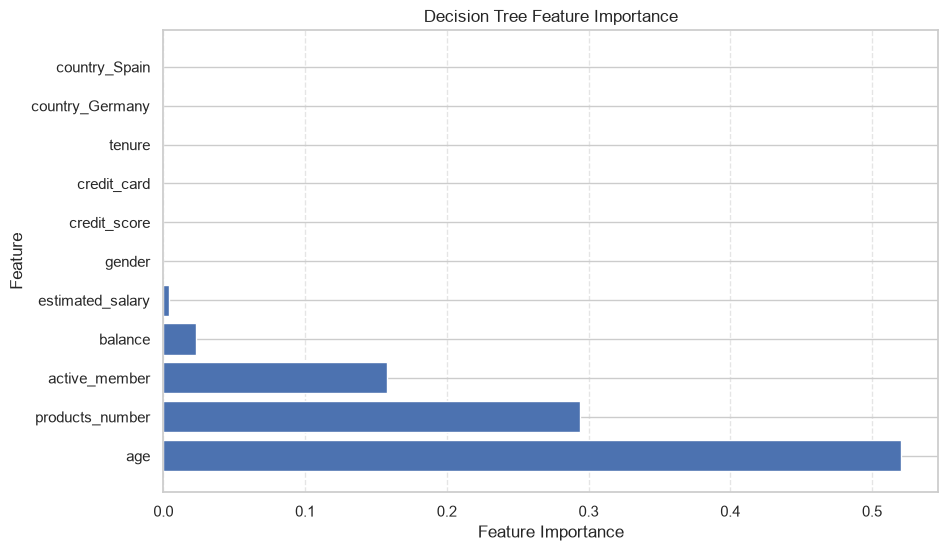

In [429]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.title("Decision Tree Feature Importance")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Interpret the Decision Tree

The Decision Tree identifies the predictors that contribute most to distinguishing between customers who churn and those who remain with the bank.

Unlike Logistic Regression, which measures the direction of each relationship using coefficients, Decision Trees evaluate variables according to how effectively they split the data into more homogeneous groups.

Consequently, feature importance in Decision Trees reflects each variable's contribution to improving classification accuracy rather than indicating whether the relationship is positive or negative.

# Interpret Feature Importance

The Decision Tree identified age, number of products, and active membership as the most influential predictors of customer churn.

Age was the most important feature, indicating that it provided the greatest reduction in node impurity throughout the tree. The number of products ranked second, suggesting that this variable was particularly effective at separating customers into groups with different churn behaviors, despite having a relatively small coefficient in the Logistic Regression model.

Active membership also remained an important predictor, supporting the findings from the exploratory data analysis and Logistic Regression. In contrast, estimated salary, credit score, tenure, credit card ownership, and country contributed little or nothing to the final Decision Tree, indicating that they did not improve the model's classification once the stronger predictors had been considered.

Comparing multiple analytical techniques strengthens confidence in the findings. Age and active membership were consistently identified as important predictors across the exploratory analysis, Logistic Regression, and Decision Tree, making them strong candidates for targeted customer retention strategies.

# Random Forest Classification

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve classification performance.

Each tree is trained using a bootstrap sample of the training dataset, while each split considers only a random subset of predictor variables. These sources of randomness produce diverse trees whose predictions are combined through majority voting.

Compared with a single Decision Tree, Random Forest generally provides better predictive accuracy, reduces overfitting, and produces more stable predictions while still allowing feature importance to be evaluated.

# Train the Random Forest Model

The Random Forest classifier is trained using the SMOTE-balanced training dataset.

Unlike a single Decision Tree, the Random Forest constructs multiple trees using different bootstrap samples of the training data and random subsets of predictor variables.

The final prediction is determined through majority voting across all trees, reducing overfitting and improving model stability.

In [430]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# Predict Customer Churn Using the Random Forest Model

The trained Random Forest model is applied to the original testing dataset.

Although the model is trained using the balanced training data produced by SMOTE, predictions are generated on the untouched testing dataset to evaluate performance under realistic customer conditions.

In [431]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [432]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.8360
Precision: 0.5806
Recall   : 0.5954
F1-score : 0.5879
ROC-AUC  : 0.8511


# Compare the Random Forest Model with Previous Models

The Random Forest classifier achieved the highest Accuracy, Precision, F1-score, and ROC-AUC among the models evaluated so far.

Compared with Logistic Regression and the Decision Tree, the Random Forest produced more balanced predictions and demonstrated a stronger ability to distinguish between customers who churn and those who remain.

Although the Decision Tree achieved a higher Recall, the Random Forest substantially improved Precision while maintaining a competitive Recall. Consequently, the Random Forest reduced unnecessary retention interventions while still identifying a large proportion of customers at risk of churn.

Overall, the Random Forest provided the best predictive performance among the models developed at this stage of the project.

# Measure Random Forest Feature Importance

Random Forest estimates feature importance by measuring the average reduction in node impurity contributed by each predictor across all Decision Trees in the forest.

Unlike a single Decision Tree, the importance values are averaged over many trees, making them generally more stable and less sensitive to individual training observations.

The importance values are normalized so that they sum to one.

In [433]:
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance

,Feature,Importance
2,age,0.283883
5,products_number,0.132779
4,balance,0.123337
8,estimated_salary,0.114743
0,credit_score,0.112638
3,tenure,0.100771
7,active_member,0.061179
9,country_Germany,0.022028
1,gender,0.017648
6,credit_card,0.016164


# Visualize Random Forest Feature Importance

A horizontal bar chart is used to visualize the contribution of each predictor to the Random Forest model.

Higher importance values indicate that a variable contributed more frequently and more effectively to the classification decisions across the ensemble of Decision Trees.

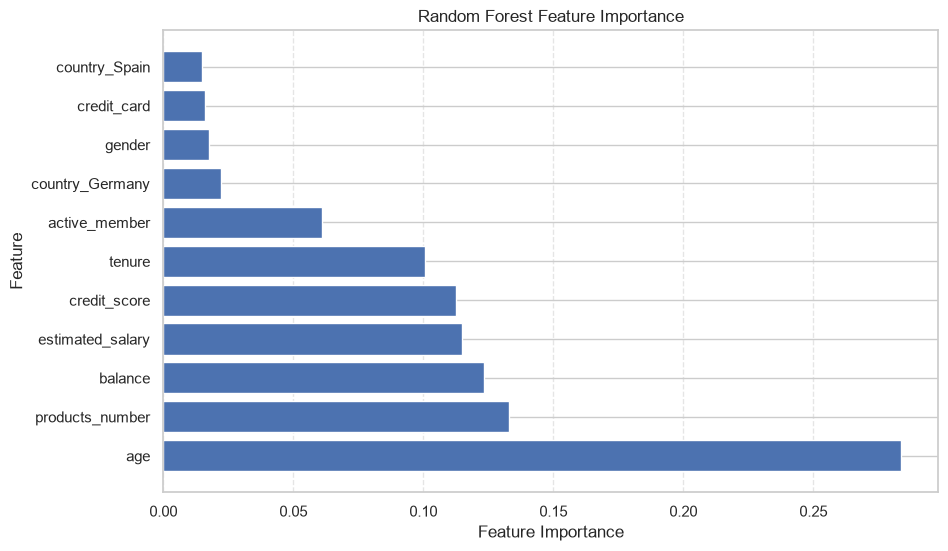

In [434]:
plt.figure(figsize=(10,6))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Interpret Random Forest Feature Importance

The Random Forest model identified age as the most influential predictor of customer churn, followed by the number of products and account balance.

Unlike the Decision Tree, which concentrated most of its importance on a few variables, the Random Forest distributed importance across a larger set of predictors because it combines the results of many Decision Trees.

Age was consistently identified as an important predictor across the exploratory data analysis, Logistic Regression, Decision Tree, and Random Forest models, increasing confidence that customer age plays a significant role in predicting churn.

The number of products also emerged as an important predictor in both tree-based models, suggesting that its relationship with churn may be nonlinear and therefore not fully captured by Logistic Regression.

Overall, comparing multiple machine learning techniques provides stronger evidence for identifying the customer characteristics most strongly associated with churn than relying on a single model.

# Extreme Gradient Boosting (XGBoost)

Extreme Gradient Boosting (XGBoost) is an ensemble learning algorithm that builds Decision Trees sequentially rather than independently.

Each new tree is trained to correct the prediction errors made by the previous trees, gradually improving the overall model performance.

Compared with Random Forest, which relies on majority voting among independently trained trees, XGBoost focuses on minimizing prediction errors through iterative learning.

XGBoost is widely used in banking, finance, insurance, and many machine learning competitions because it often achieves excellent predictive performance while remaining computationally efficient.

# Train the XGBoost Model

The XGBoost classifier is trained using the SMOTE-balanced training dataset.

Unlike Random Forest, which builds multiple independent Decision Trees, XGBoost constructs trees sequentially. Each new tree focuses on correcting the prediction errors made by the previous trees, leading to progressively improved predictive performance.

The model is initially trained using a simple set of hyperparameters. Hyperparameter tuning will be considered after comparing the baseline performance of all machine learning models.

In [435]:
from xgboost import XGBClassifier

In [436]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Generate Predictions Using XGBoost

The trained XGBoost model is applied to the original testing dataset.

Predicted classes and class probabilities are generated to evaluate the model using the same performance metrics employed for the previous machine learning algorithms.

In [437]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [438]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(y_test, y_pred_xgb)

xgb_recall = recall_score(y_test, y_pred_xgb)

xgb_f1 = f1_score(y_test, y_pred_xgb)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

Accuracy : 0.8515
Precision: 0.6200
Recall   : 0.6310
F1-score : 0.6255
ROC-AUC  : 0.8658


# Compare XGBoost with Previous Models

Among the models evaluated so far, XGBoost achieved the highest Accuracy, Precision, F1-score, and ROC-AUC.

Compared with Random Forest, XGBoost demonstrated modest improvements across most evaluation metrics while maintaining a competitive Recall. The higher ROC-AUC indicates a stronger ability to distinguish between customers who churn and those who remain with the bank.

Although the Decision Tree achieved the highest Recall, XGBoost provided a more balanced overall performance by substantially reducing false positive predictions while maintaining good sensitivity to customers at risk of churn.

Based on the current results, XGBoost represents the strongest predictive model developed in this project.

# LightGBM Classification

LightGBM (Light Gradient Boosting Machine) is a gradient boosting algorithm that builds Decision Trees sequentially to improve predictive performance.

Like XGBoost, each new tree attempts to correct the prediction errors made by the previous trees. However, LightGBM is specifically designed to train more efficiently on large datasets by using optimized tree-growing techniques.

The model is trained using the SMOTE-balanced training dataset and evaluated using the same performance metrics as the previous machine learning models.

In [439]:
from lightgbm import LGBMClassifier

# Train the LightGBM Model

The LightGBM classifier is trained using the balanced training dataset produced by SMOTE.

The selected hyperparameters provide a baseline model for comparison with the other machine learning algorithms evaluated in this project.

In [440]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)

,max_depth,4
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


# Generate Predictions Using LightGBM

The trained LightGBM model is applied to the original testing dataset to generate predicted customer classes and churn probabilities.

The testing dataset remains unchanged to ensure a fair comparison across all machine learning models.

In [441]:
y_pred_lgbm = lgbm_model.predict(X_test)

y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate the LightGBM Model

The LightGBM classifier is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Using the same evaluation metrics enables an objective comparison with Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [442]:
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)

lgbm_precision = precision_score(y_test, y_pred_lgbm)

lgbm_recall = recall_score(y_test, y_pred_lgbm)

lgbm_f1 = f1_score(y_test, y_pred_lgbm)

lgbm_auc = roc_auc_score(y_test, y_prob_lgbm)

print(f"Accuracy : {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall   : {lgbm_recall:.4f}")
print(f"F1-score : {lgbm_f1:.4f}")
print(f"ROC-AUC  : {lgbm_auc:.4f}")

Accuracy : 0.8480
Precision: 0.6052
Recall   : 0.6514
F1-score : 0.6275
ROC-AUC  : 0.8645


# Compare LightGBM with Previous Models

The LightGBM classifier achieved performance comparable to XGBoost across all evaluation metrics.

Although XGBoost achieved slightly higher Accuracy, Precision, and ROC-AUC, LightGBM produced a marginally higher F1-score and Recall. These small differences suggest that both gradient boosting algorithms provide excellent predictive performance for customer churn prediction.

Because the observed differences are relatively small, additional validation using cross-validation is required before selecting the final model.

# Measure LightGBM Feature Importance

LightGBM estimates feature importance by measuring the contribution of each predictor across all boosted Decision Trees.

The resulting importance scores help identify the variables that contribute most to customer churn prediction and can be compared with the findings from the previous machine learning models.

In [443]:
lgbm_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

lgbm_feature_importance = lgbm_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

lgbm_feature_importance

,Feature,Importance
2,age,365
3,tenure,229
4,balance,185
5,products_number,162
8,estimated_salary,140
0,credit_score,107
7,active_member,61
9,country_Germany,49
1,gender,25
10,country_Spain,13


# Interpret LightGBM Feature Importance

The LightGBM model identified age as the most influential predictor of customer churn, followed by tenure, account balance, and the number of banking products.

Unlike earlier models, LightGBM assigned greater importance to tenure, suggesting that customer loyalty and account duration contribute more strongly when nonlinear interactions between variables are considered.

Age remained the most important predictor across all tree-based models evaluated in this project, reinforcing the conclusion that customer age plays a major role in churn prediction.

Overall, the feature importance rankings produced by LightGBM are broadly consistent with those obtained from the Decision Tree and Random Forest models, increasing confidence in the robustness of the identified predictors.

# CatBoost Classification

CatBoost is a gradient boosting algorithm designed to provide high predictive performance while effectively handling categorical features and reducing overfitting.

Like XGBoost and LightGBM, CatBoost builds Decision Trees sequentially, with each new tree correcting the errors made by previous trees. The model is trained using the SMOTE-balanced training dataset and evaluated using the same performance metrics as the other machine learning algorithms.

In [444]:
from catboost import CatBoostClassifier

# Train the CatBoost Model

The CatBoost classifier is trained using the balanced training dataset produced by SMOTE.

The model is configured with a baseline set of hyperparameters to enable a fair comparison with the previously evaluated machine learning algorithms.

In [445]:
cat_model = CatBoostClassifier(
    iterations=100,
    depth=4,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

cat_model.fit(
    X_train_smote,
    y_train_smote
)

CatBoostClassifier(depth=4, iterations=100, learning_rate=0.1, random_state=42, verbose=0)

# Generate Predictions Using CatBoost

The trained CatBoost model is applied to the original testing dataset to generate predicted customer classes and churn probabilities.

The testing dataset remains unchanged to ensure a fair comparison with the other machine learning models.

In [446]:
y_pred_cat = cat_model.predict(X_test)

y_prob_cat = cat_model.predict_proba(X_test)[:,1]

# Evaluate the CatBoost Model

The CatBoost classifier is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The resulting performance metrics are compared with the other machine learning models developed in this project.

In [447]:
cat_accuracy = accuracy_score(y_test, y_pred_cat)

cat_precision = precision_score(y_test, y_pred_cat)

cat_recall = recall_score(y_test, y_pred_cat)

cat_f1 = f1_score(y_test, y_pred_cat)

cat_auc = roc_auc_score(y_test, y_prob_cat)

print(f"Accuracy : {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall   : {cat_recall:.4f}")
print(f"F1-score : {cat_f1:.4f}")
print(f"ROC-AUC  : {cat_auc:.4f}")

Accuracy : 0.8295
Precision: 0.5483
Recall   : 0.7506
F1-score : 0.6337
ROC-AUC  : 0.8692


# Measure CatBoost Feature Importance

The importance of each predictor is calculated using the trained CatBoost model.

Comparing the feature importance across all machine learning models helps identify variables that consistently contribute to customer churn prediction.

In [448]:
cat_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
})

cat_feature_importance = cat_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

cat_feature_importance

,Feature,Importance
5,products_number,29.022778
2,age,25.312008
3,tenure,17.826138
7,active_member,9.783831
4,balance,8.661794
9,country_Germany,5.589212
8,estimated_salary,0.997823
1,gender,0.901275
10,country_Spain,0.821816
0,credit_score,0.769462


# Final Comparison of Machine Learning Models

The predictive performance of all machine learning models developed in this project is compared using identical evaluation metrics.

The comparison includes Accuracy, Precision, Recall, F1-score, and ROC-AUC, allowing the strengths and weaknesses of each algorithm to be evaluated from both technical and business perspectives.

The best-performing values for each metric are highlighted to facilitate model selection before performing cross-validation and explainability analysis.

In [449]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Logistic Regression": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        auc_smote
    ],

    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ],

    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ],

    "LightGBM": [
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1,
        lgbm_auc
    ],

    "CatBoost": [
        cat_accuracy,
        cat_precision,
        cat_recall,
        cat_f1,
        cat_auc
    ]
})

final_comparison = final_comparison.set_index("Metric")

final_comparison = final_comparison.round(4)

final_comparison

,Logistic Regression,Decision Tree,Random Forest,XGBoost,LightGBM,CatBoost
Metric,,,,,,
Accuracy,0.7125,0.7545,0.8360,0.8515,0.8480,0.8295
Precision,0.3767,0.4255,0.5806,0.6200,0.6052,0.5483
Recall,0.7074,0.7125,0.5954,0.6310,0.6514,0.7506
F1-score,0.4916,0.5328,0.5879,0.6255,0.6275,0.6337
ROC-AUC,0.7764,0.8123,0.8511,0.8658,0.8645,0.8692


In [450]:
final_comparison_percent = (final_comparison * 100).round(2)

final_comparison_percent.style.format("{:.2f}%").highlight_max(axis=1)



,Logistic Regression,Decision Tree,Random Forest,XGBoost,LightGBM,CatBoost
Metric,,,,,,
Accuracy,71.25%,75.45%,83.60%,85.15%,84.80%,82.95%
Precision,37.67%,42.55%,58.06%,62.00%,60.52%,54.83%
Recall,70.74%,71.25%,59.54%,63.10%,65.14%,75.06%
F1-score,49.16%,53.28%,58.79%,62.55%,62.75%,63.37%
ROC-AUC,77.64%,81.23%,85.11%,86.58%,86.45%,86.92%


# Final Model Comparison

Six supervised machine learning models were developed and evaluated using identical preprocessing steps and evaluation metrics.

Among the evaluated models, CatBoost achieved the highest Recall, F1-score, and ROC-AUC, while XGBoost achieved the highest Accuracy and Precision.

The relatively small performance differences between the boosting algorithms indicate that all three ensemble methods (Random Forest, XGBoost, LightGBM, and CatBoost) provide strong predictive performance for customer churn prediction.

Because the observed differences are modest, additional validation using 5-fold cross-validation is performed before selecting the final model for deployment.

# Validate the Models Using 5-Fold Cross-Validation

The initial model comparison was based on a single training and testing split. Although this provides useful information, the results may be influenced by the specific customers assigned to each subset.

To obtain a more reliable estimate of model performance, stratified 5-fold cross-validation is used.

The training dataset is divided into five approximately equal folds. During each iteration:

1. Four folds are used to train the model.
2. The remaining fold is used for validation.
3. The process is repeated until every fold has served as the validation set.

Stratification preserves approximately the same proportion of churned and non-churned customers in each fold.

SMOTE is applied only within the training portion of each fold. This prevents data leakage and ensures that synthetic observations do not influence the corresponding validation fold.

# Prepare the Unscaled Training Data

Feature scaling and SMOTE must be performed independently within every cross-validation fold.

Therefore, the original encoded but unscaled training observations are reconstructed using the row indices from the initial train-test split. The separate testing dataset remains reserved for final model evaluation.

In [451]:
# Recover the encoded but unscaled training observations
X_train_cv = X.loc[X_train.index].copy()
y_train_cv = y.loc[y_train.index].copy()

print("Cross-validation features:", X_train_cv.shape)
print("Cross-validation target:", y_train_cv.shape)

Cross-validation features: (8000, 11)
Cross-validation target: (8000,)


# Create the Cross-Validation Preprocessing Pipeline

A column transformer is used to standardize the continuous numerical variables while leaving binary and one-hot encoded variables unchanged.

This preprocessing step is fitted separately during each cross-validation iteration. SMOTE is then applied only to the transformed training folds before the model is trained.

Placing preprocessing, SMOTE, and model training inside one pipeline prevents information from the validation fold from influencing the training process.

In [452]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

numerical_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]

binary_features = [
    "gender",
    "credit_card",
    "active_member",
    "country_Germany",
    "country_Spain"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("binary", "passthrough", binary_features)
    ]
)

# Configure Stratified 5-Fold Cross-Validation

StratifiedKFold divides the training observations into five folds while maintaining approximately the same churn distribution in each fold.

Shuffling reduces the influence of the original row order, while the fixed random state ensures that the folds can be reproduced.

In [453]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the Cross-Validation Metrics

The models are evaluated using the same performance measures used during the initial train-test comparison:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Using consistent metrics allows the cross-validation results to be compared directly with the earlier model results.

In [454]:
scoring_metrics = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

# Define the Models for Cross-Validation

The six classification algorithms developed in this project are stored in a dictionary.

Each model will be placed inside the same preprocessing and SMOTE pipeline, ensuring that all algorithms are validated under consistent experimental conditions.

In [455]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=100,
        depth=4,
        learning_rate=0.1,
        random_state=42,
        verbose=0,
        thread_count=-1
    )
}

# Perform 5-Fold Cross-Validation

Each model is evaluated across five validation folds.

For every model and every fold, the following sequence is performed:

1. Fit the preprocessing transformer using the training folds.
2. Standardize the numerical variables.
3. Apply SMOTE only to the training folds.
4. Train the classification model.
5. Evaluate the model on the untouched validation fold.

The mean and standard deviation of each metric are recorded. The mean represents average predictive performance, while the standard deviation indicates how stable the performance is across different folds.

In [456]:
import pandas as pd
from sklearn.model_selection import cross_validate

cv_results = []

for model_name, estimator in models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", estimator)
        ]
    )

    scores = cross_validate(
        estimator=model_pipeline,
        X=X_train_cv,
        y=y_train_cv,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=1,
        error_score="raise"
    )

    cv_results.append({
        "Model": model_name,

        "Accuracy Mean": scores["test_Accuracy"].mean(),
        "Accuracy Std": scores["test_Accuracy"].std(),

        "Precision Mean": scores["test_Precision"].mean(),
        "Precision Std": scores["test_Precision"].std(),

        "Recall Mean": scores["test_Recall"].mean(),
        "Recall Std": scores["test_Recall"].std(),

        "F1-score Mean": scores["test_F1-score"].mean(),
        "F1-score Std": scores["test_F1-score"].std(),

        "ROC-AUC Mean": scores["test_ROC-AUC"].mean(),
        "ROC-AUC Std": scores["test_ROC-AUC"].std()
    })

cross_validation_results = pd.DataFrame(cv_results)

# Display the Cross-Validation Results

The cross-validation table reports the average performance and variability of each model across the five folds.

Higher mean values indicate stronger predictive performance. Lower standard deviations indicate that the model produces more consistent results across different samples of customers.

In [457]:
cross_validation_results = (
    cross_validation_results
    .sort_values(by="F1-score Mean", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

cross_validation_results

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-score Mean,F1-score Std,ROC-AUC Mean,ROC-AUC Std
0,LightGBM,0.8525,0.0121,0.6525,0.0353,0.6071,0.0207,0.6287,0.0258,0.8621,0.0104
1,CatBoost,0.8407,0.0081,0.6049,0.0185,0.6496,0.0299,0.6262,0.0206,0.8659,0.0090
2,XGBoost,0.8479,0.0146,0.6372,0.0412,0.6089,0.0213,0.6224,0.0292,0.8608,0.0099
3,Random Forest,0.8491,0.0077,0.6569,0.0240,0.5578,0.0176,0.6031,0.0180,0.8489,0.0110
4,Decision Tree,0.7581,0.0261,0.4473,0.0417,0.6722,0.0451,0.5342,0.0160,0.8022,0.0071
5,Logistic Regression,0.7080,0.0114,0.3825,0.0116,0.6825,0.0263,0.4900,0.0115,0.7652,0.0117


# Interpretation of 5-Fold Cross-Validation Results

The 5-fold cross-validation results demonstrate that the gradient boosting models produced the strongest and most stable predictive performance.

LightGBM achieved the highest average Accuracy and F1-score, indicating the strongest overall balance between correctly identifying churners and limiting false positive predictions. CatBoost achieved the highest average ROC-AUC and produced higher Recall than LightGBM, demonstrating a strong and consistent ability to distinguish customers who churn from those who remain.

Although Logistic Regression achieved the highest Recall, its substantially lower Precision and F1-score indicate that this improvement was accompanied by a large number of false positive predictions. Random Forest achieved the highest Precision but lower Recall, meaning that its predicted churn list was more reliable but excluded a larger proportion of actual churners.

Because the differences between LightGBM and CatBoost were small, both models represent strong candidates. CatBoost is selected as the primary model for explainability and customer segmentation because it achieved the highest ROC-AUC, competitive F1-score, and stronger Recall, aligning well with the project's customer-retention objective.

# Select the Final Model for Explainability

CatBoost is selected for SHAP analysis because it demonstrated strong and stable predictive performance across the five cross-validation folds.

The model achieved the highest average ROC-AUC while maintaining competitive Accuracy, Recall, and F1-score. This balance makes it suitable for ranking customers according to churn risk and supporting targeted retention decisions.

SHAP will be used to explain the direction and magnitude of each feature's contribution to the model's predictions at both the overall model level and the individual customer level.

# Explain the Final Model Using SHAP

Although the CatBoost model demonstrated strong predictive performance, understanding why the model makes its predictions is equally important.

SHAP (SHapley Additive exPlanations) is used to explain the contribution of each predictor to the model's predictions. Unlike traditional feature importance measures, SHAP quantifies both the magnitude and the direction of each feature's influence.

SHAP analysis is performed at two levels:

- Global explanations identify the variables that are most influential across all customers.
- Local explanations explain why the model predicts a particular customer is likely to churn.

In [458]:
import shap

# Initialize the SHAP Explainer

A TreeExplainer is created for the trained CatBoost model.

TreeExplainer is specifically designed for tree-based machine learning algorithms and provides efficient computation of SHAP values.

In [459]:
explainer = shap.TreeExplainer(cat_model)

# Calculate SHAP Values

SHAP values are calculated for the testing dataset.

Each SHAP value represents the contribution of one predictor to the prediction of customer churn for an individual customer.

In [460]:
shap_values = explainer.shap_values(X_test)

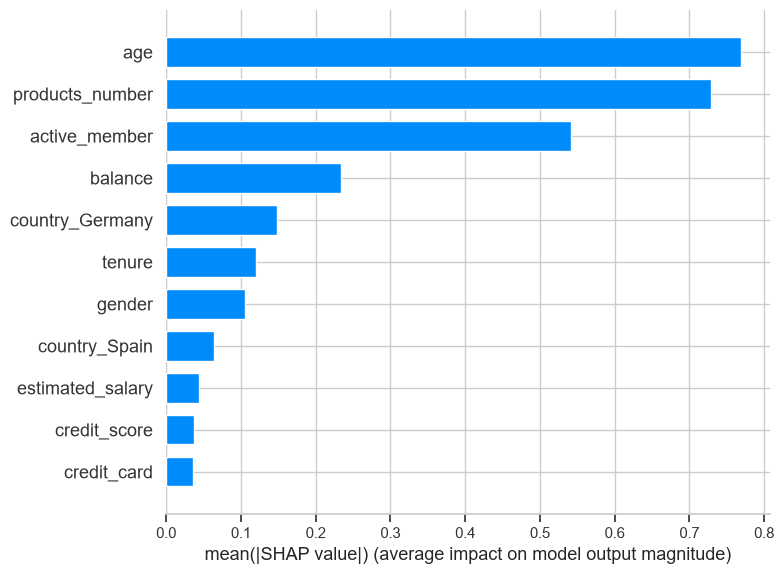

In [461]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# Interpretation of the SHAP Global Feature Importance

The SHAP summary plot provides the average contribution of each predictor to the CatBoost model's churn predictions.

Age was identified as the most influential predictor, followed by the number of banking products and active membership. These findings are consistent with the results obtained from the Decision Tree, Random Forest, LightGBM, and CatBoost feature importance analyses, increasing confidence in the robustness of the identified predictors.

The SHAP analysis also confirms that estimated salary, credit score, and credit card ownership contribute relatively little to the model's predictions. Although these variables may provide additional information in combination with other predictors, their overall influence on customer churn is comparatively small.

Overall, the agreement between SHAP and the previous machine learning models strengthens the conclusion that customer age, product ownership, customer activity, account balance, and tenure are the primary drivers of customer churn within this dataset.

# Visualize the Direction of Feature Effects

The SHAP beeswarm plot illustrates both the importance and the direction of each feature's contribution to customer churn predictions.

Each point represents one customer.

The horizontal position indicates whether the feature increases or decreases the predicted probability of churn, while the color represents whether the feature value is relatively high (red) or low (blue).

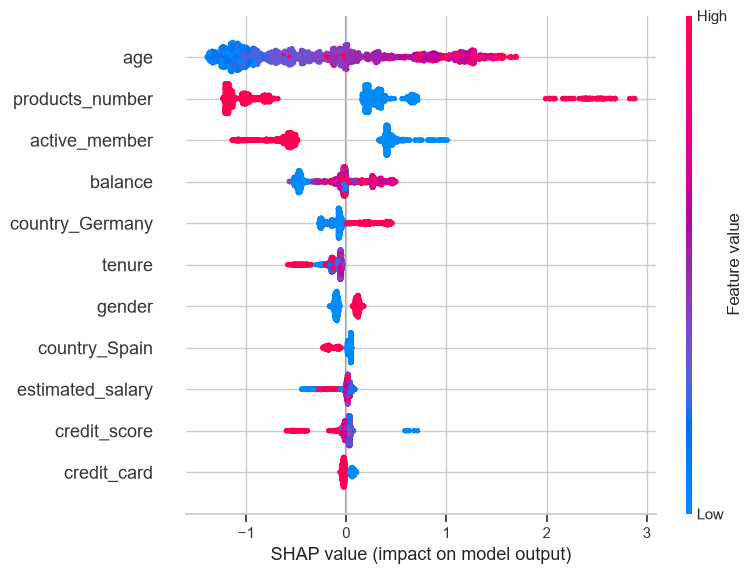

In [462]:
shap.summary_plot(
    shap_values,
    X_test
)

# Interpretation of the SHAP Beeswarm Plot

The SHAP beeswarm plot provides both the importance and direction of each predictor's contribution to customer churn.

Older customers generally produce positive SHAP values, indicating that increasing age raises the predicted probability of customer churn. In contrast, younger customers tend to reduce the predicted churn probability.

Active membership shows the opposite pattern. Active customers generally decrease churn predictions, while inactive customers increase the predicted probability of churn. This finding suggests that customer engagement is one of the strongest protective factors against churn.

The number of banking products also has a substantial influence on the model's predictions. SHAP indicates that its effect is nonlinear, confirming the findings from the tree-based models and demonstrating that product ownership interacts with other customer characteristics.

Account balance and tenure contribute to churn prediction but exhibit more complex patterns, indicating that their effects depend on combinations with other predictors rather than acting independently.

Overall, the SHAP analysis confirms that age, product ownership, active membership, balance, and tenure are the principal drivers of customer churn in the final CatBoost model.

# Analyze the Effect of the Number of Banking Products

Although the SHAP summary plot identified the number of banking products as one of the most influential predictors, it does not clearly indicate how different product counts affect the predicted probability of customer churn.

A SHAP dependence plot is used to visualize the relationship between the number of banking products and its contribution to the CatBoost model's predictions.

This analysis helps determine whether the relationship is linear or whether specific product counts are associated with substantially higher churn risk.

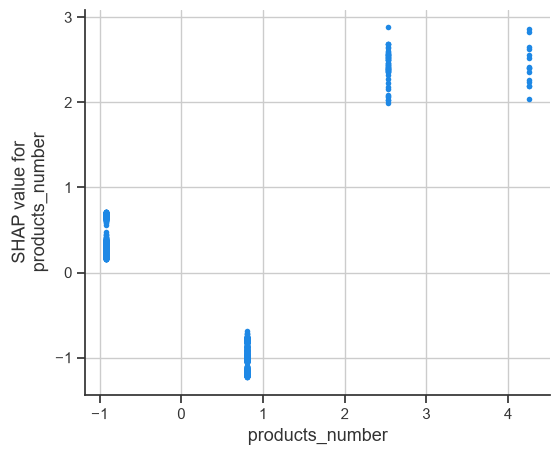

In [463]:
shap.dependence_plot(
    "products_number",
    shap_values,
    X_test,
    interaction_index=None
)

# Interpretation of the SHAP Dependence Plot for the Number of Banking Products

The SHAP dependence plot demonstrates that the relationship between the number of banking products and customer churn is nonlinear.

Customers holding two banking products generally exhibit negative SHAP values, indicating that this product count reduces the predicted probability of churn. In contrast, customers holding one product show slightly positive SHAP values, while customers with three or four products display substantially positive SHAP values, indicating an increased likelihood of churn.

This finding explains why tree-based machine learning models consistently identified the number of products as one of the strongest predictors of customer churn, whereas Logistic Regression assigned it relatively little importance. The relationship cannot be adequately described by a simple linear trend.

From a business perspective, these results suggest that customers with three or more products represent an important segment for further investigation and targeted retention initiatives. However, additional business analysis would be required to determine the underlying reasons for this pattern.

# Analyze the Effect of Customer Age

Age was consistently identified as the most influential predictor across the exploratory data analysis, multiple machine learning models, and SHAP global feature importance.

A SHAP dependence plot is used to examine how customer age influences the predicted probability of churn and to determine whether the relationship is linear or nonlinear.

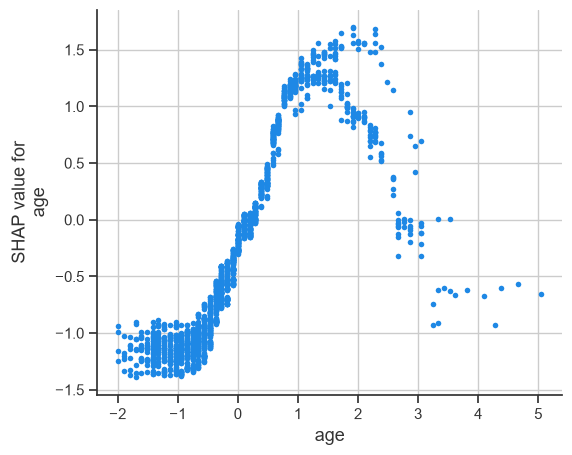

In [464]:
shap.dependence_plot(
    "age",
    shap_values,
    X_test,
    interaction_index=None
)

# Interpretation of the SHAP Dependence Plot for Customer Age

The SHAP dependence plot demonstrates that the relationship between customer age and churn is nonlinear.

Younger customers generally exhibit negative SHAP values, indicating that lower ages reduce the predicted probability of churn. As customer age increases, the SHAP values gradually become positive, suggesting that middle-aged customers have a substantially higher predicted risk of churn.

Interestingly, the SHAP values decline for the oldest customers in the dataset, indicating that churn risk does not continue increasing indefinitely with age. Instead, the relationship follows a nonlinear pattern in which churn risk rises with age before decreasing among the oldest customer groups.

This finding helps explain why the tree-based ensemble models consistently outperformed Logistic Regression. Unlike linear models, boosting algorithms can naturally learn nonlinear relationships between customer characteristics and churn.

From a business perspective, the results suggest that middle-aged customers represent an important segment for proactive retention initiatives, while additional investigation is recommended to understand the factors contributing to the lower predicted churn risk among the oldest customers.

# Customer Segmentation for Retention Strategies

The CatBoost model estimates the probability that each customer will leave the bank. However, effective retention strategies require more than identifying customers who are likely to churn.

Customers are segmented according to two dimensions:

- Predicted churn risk, obtained from the final CatBoost model.
- Estimated customer value, approximated using the available customer information.

This approach allows the bank to prioritize retention efforts toward customers who represent both a high risk of churn and high business value.

# Predict Churn Probabilities for All Customers

The trained CatBoost model is applied to the complete dataset to estimate the probability of churn for every customer.

These probabilities will be used to classify customers into different retention priority groups.

In [465]:
customer_segmentation = X.copy()

customer_segmentation["Churn_Probability"] = cat_model.predict_proba(X)[:, 1]

customer_segmentation.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,Churn_Probability
0,619,1,42,2,0.00,1,1,1,101348.88,0,0,0.226327
1,608,1,41,1,83807.86,1,0,1,112542.58,0,1,0.441446
2,502,1,42,8,159660.80,3,1,0,113931.57,0,0,0.936768
3,699,1,39,1,0.00,2,0,0,93826.63,0,0,0.917489
4,850,1,43,2,125510.82,1,1,1,79084.10,0,1,0.281877


# Classify Customers by Churn Risk

Customers are categorized into three churn-risk groups according to their predicted probability of leaving the bank.

These categories simplify the interpretation of model predictions and support the prioritization of customer retention initiatives.

In [466]:
customer_segmentation["Churn_Risk"] = pd.qcut(
    customer_segmentation["Churn_Probability"],
    q=[0, 0.25, 0.75, 1],
    labels=["Low", "Medium", "High"]
)

customer_segmentation["Churn_Risk"].value_counts()

Churn_Risk
Medium    5018
Low       2522
High      2460
Name: count, dtype: int64

# Estimate Customer Value

The dataset does not contain direct measures of customer lifetime value, profitability, or revenue contribution.

Therefore, customer value is approximated using the available banking information. Customers with larger account balances, more banking products, and active membership are assumed to represent greater long-term value to the bank.

This estimated value is used only for customer segmentation and should not be interpreted as an exact financial valuation.

In [467]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

customer_segmentation["Balance_Score"] = scaler.fit_transform(
    customer_segmentation[["balance"]]
)

customer_segmentation["Products_Score"] = scaler.fit_transform(
    customer_segmentation[["products_number"]]
)

customer_segmentation["Activity_Score"] = customer_segmentation["active_member"]

customer_segmentation["Customer_Value"] = (
    0.5 * customer_segmentation["Balance_Score"] +
    0.3 * customer_segmentation["Products_Score"] +
    0.2 * customer_segmentation["Activity_Score"]
)

# Classify Customer Value

Customers are divided into High and Low value groups according to the estimated customer value score.

The median value score is used as the threshold, creating two groups of approximately equal size for managerial decision-making.

In [468]:
customer_segmentation["Customer_Value_Level"] = np.where(
    customer_segmentation["Customer_Value"] >= customer_segmentation["Customer_Value"].median(),
    "High",
    "Low"
)

customer_segmentation["Customer_Value_Level"].value_counts()

Customer_Value_Level
High    5806
Low     4194
Name: count, dtype: int64

# Create the Customer Retention Matrix

Customer churn risk and estimated customer value are combined to create strategic customer segments.

This matrix helps managers prioritize retention resources by identifying customers who are both likely to churn and valuable to the bank.

In [469]:
customer_segmentation["Retention_Segment"] = (
    customer_segmentation["Churn_Risk"].astype(str)
    + " Risk - "
    + customer_segmentation["Customer_Value_Level"]
    + " Value"
)

customer_segmentation["Retention_Segment"].value_counts()

Retention_Segment
Medium Risk - High Value    3115
Low Risk - High Value       2071
Medium Risk - Low Value     1903
High Risk - Low Value       1840
High Risk - High Value       620
Low Risk - Low Value         451
Name: count, dtype: int64

# Cross-Tabulation of Customer Segments

A contingency table summarizes the number of customers within each combination of churn risk and customer value.

This table provides a concise overview of the customer portfolio and highlights the groups that should receive different retention strategies.

In [470]:
segment_table = pd.crosstab(
    customer_segmentation["Customer_Value_Level"],
    customer_segmentation["Churn_Risk"],
    margins=True
)

segment_table

Churn_Risk,Low,Medium,High,All
Customer_Value_Level,,,,
High,2071,3115,620,5806
Low,451,1903,1840,4194
All,2522,5018,2460,10000


# Interpretation of the Customer Retention Matrix

The customer retention matrix combines predicted churn risk with estimated customer value to support retention decision-making.

The analysis identified 620 customers who are both high-value and at high risk of churn. These customers represent the highest retention priority because losing them could have a significant financial impact on the bank. Personalized retention strategies, including proactive outreach and tailored offers, should be directed toward this segment.

A larger group of 3,115 customers falls into the medium-risk, high-value category. Although these customers are not at immediate risk of leaving, preventive engagement strategies such as loyalty programs, financial reviews, and personalized communication may help maintain long-term relationships.

Most high-risk customers (1,840) belong to the low-value segment. Because the potential financial return is lower, cost-effective retention strategies such as automated email campaigns or digital promotions may be more appropriate than intensive one-to-one interventions.

Overall, combining churn probability with estimated customer value enables the bank to allocate retention resources more efficiently than relying solely on churn predictions.

# Create the Customer Retention Strategy Table

A business recommendation table is created to translate each customer segment into a retention priority and a recommended managerial action.

This table provides a practical decision framework that allows the bank to allocate retention resources according to both predicted churn risk and estimated customer value.

# Recommended Customer Retention Strategies

| Customer Segment | Priority | Recommended Strategy |
|------------------|----------|----------------------|
| High Risk – High Value | Very High | Immediate personal contact, relationship manager, exclusive retention offers |
| High Risk – Low Value | High | Automated retention campaigns, targeted digital promotions |
| Medium Risk – High Value | High | Loyalty rewards, personalized financial advice, proactive engagement |
| Medium Risk – Low Value | Medium | Regular marketing communications and product recommendations |
| Low Risk – High Value | Medium | Maintain customer satisfaction through premium services and loyalty benefits |
| Low Risk – Low Value | Low | Routine monitoring with minimal intervention |

# Visualize the Customer Retention Matrix

A heatmap is used to visualize the number of customers in each combination of churn risk and customer value.

Darker cells represent larger customer groups. The visualization helps management quickly identify the segments containing the greatest number of customers and supports the prioritization of retention resources.

The high-risk, high-value segment remains the most urgent group even if it is not the largest, because these customers combine elevated churn risk with greater estimated business value.

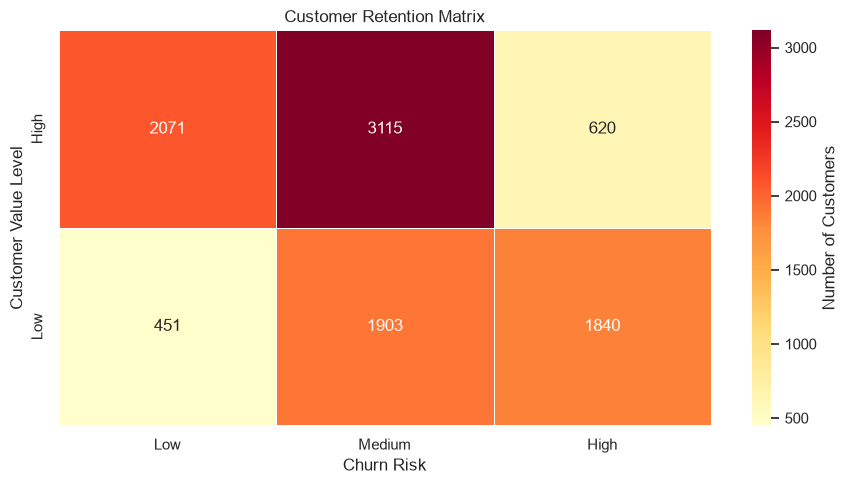

In [471]:
# Create the segment matrix without totals
retention_heatmap = pd.crosstab(
    customer_segmentation["Customer_Value_Level"],
    customer_segmentation["Churn_Risk"]
)

# Arrange rows and columns in a logical order
retention_heatmap = retention_heatmap.reindex(
    index=["High", "Low"],
    columns=["Low", "Medium", "High"]
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.heatmap(
    retention_heatmap,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Number of Customers"}
)

plt.title("Customer Retention Matrix")
plt.xlabel("Churn Risk")
plt.ylabel("Customer Value Level")

plt.tight_layout()
plt.show()

# Project Limitations

Although the developed machine learning models demonstrated strong predictive performance, several limitations should be considered when interpreting the results.

First, the analysis was conducted using a publicly available Kaggle dataset rather than real banking data. Consequently, the results may not fully represent the complexity of customer behavior in an actual financial institution.

Second, the dataset does not include important variables such as customer transaction history, customer lifetime value, product profitability, complaint history, digital banking activity, customer satisfaction, marketing interactions, or call center records. Including these variables could improve predictive performance and provide a more comprehensive understanding of customer churn.

Third, customer value was estimated using account balance, number of products, and active membership because direct financial value measures were unavailable. Therefore, the customer segmentation should be interpreted as an approximation rather than an exact measure of customer profitability.

Finally, although SMOTE improved the model's ability to detect churning customers, synthetic observations may not perfectly represent real customer behavior. The use of cross-validation helped reduce this limitation by providing a more robust estimate of model performance.

# Future Work

Several opportunities exist to extend this project.

Future research could evaluate additional machine learning techniques such as deep neural networks, cost-sensitive learning, and automated hyperparameter optimization to further improve predictive performance.

The incorporation of real banking data, including transaction histories, customer service interactions, digital engagement metrics, and profitability information, would allow more accurate customer value estimation and retention strategy development.

Future studies may also investigate time-series models that monitor changes in customer behavior over time, enabling earlier detection of customers at risk of churn.

Finally, deploying the selected machine learning model within a real-time banking environment would allow churn probabilities to be updated continuously, supporting proactive customer retention decisions.

# Final Conclusion

This project investigated whether machine learning techniques can accurately predict customer churn in retail banking and support customer retention strategies.

Following the CRISP-DM methodology, customer data were explored, preprocessed, balanced using SMOTE, and analyzed using six supervised machine learning algorithms: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost.

Model performance was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and 5-fold cross-validation. The results demonstrated that ensemble boosting methods consistently achieved the strongest predictive performance. CatBoost achieved the highest ROC-AUC and Recall, while LightGBM achieved the highest average Accuracy and F1-score during cross-validation.

SHAP explainability confirmed that customer age, number of banking products, active membership, account balance, and tenure are the principal drivers of customer churn. Customer segmentation further demonstrated how predicted churn risk can be combined with estimated customer value to prioritize retention resources efficiently.

Overall, the findings indicate that machine learning can effectively support retail banks in identifying customers at risk of churn and developing targeted retention strategies. Beyond achieving strong predictive performance, the project demonstrates how predictive analytics can be translated into practical business decisions that improve customer relationship management and resource allocation.

# Executive Summary

## Project Overview

This project investigates whether machine learning can accurately predict customer churn in retail banking and support more effective customer retention strategies. Following the CRISP-DM methodology, customer data were explored, preprocessed, balanced using SMOTE, and analyzed using six supervised machine learning algorithms. Model performance was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and 5-fold cross-validation. SHAP explainability was then applied to interpret the final model, and customer segmentation was developed to translate predictions into actionable business recommendations.

---

## Dataset Summary

| Item | Value |
|------|-------|
| Dataset | Bank Customer Churn (Kaggle) |
| Total Customers | 10,000 |
| Features Used | 11 |
| Target Variable | Customer Churn |
| Initial Churn Rate | 20.4% |
| Methodology | CRISP-DM |

---

## Machine Learning Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

All models were trained on a SMOTE-balanced training dataset and evaluated using 5-fold cross-validation.

---

## Model Performance Summary

| Metric | Best Model | Result |
|---------|------------|-------:|
| Accuracy | LightGBM | 85.25% |
| Precision | Random Forest | 65.69% |
| Recall | Logistic Regression | 68.25% |
| F1-score | LightGBM | 62.87% |
| ROC-AUC | CatBoost | 86.59% |

Overall, the boosting algorithms (LightGBM, XGBoost, and CatBoost) consistently achieved the strongest predictive performance. CatBoost was selected as the final explainable model because it combined a high ROC-AUC, competitive F1-score, and strong Recall.

---

## Key Drivers of Customer Churn

The SHAP analysis identified the following variables as the most influential predictors of customer churn:

1. Customer Age
2. Number of Banking Products
3. Active Membership
4. Account Balance
5. Customer Tenure

The analysis also revealed nonlinear relationships that were not evident during the initial exploratory data analysis, particularly for customer age and the number of banking products.

---

## Business Insights

- Older and middle-aged customers exhibit a higher predicted risk of churn.
- Customers with two banking products demonstrate the lowest churn risk, while those with three or four products exhibit substantially higher predicted churn risk.
- Active membership significantly reduces the likelihood of customer churn.
- Combining churn probability with estimated customer value enables more effective prioritization of retention resources.

---

## Recommended Retention Strategy

| Customer Segment | Recommended Action |
|------------------|--------------------|
| High Risk – High Value | Immediate personalized retention and relationship manager follow-up |
| High Risk – Low Value | Automated digital retention campaigns |
| Medium Risk – High Value | Loyalty programs and proactive engagement |
| Low Risk – High Value | Premium relationship management and customer satisfaction initiatives |

---

## Conclusion

The results demonstrate that machine learning can accurately predict customer churn and provide valuable decision support for customer retention. Beyond predictive performance, integrating explainable artificial intelligence (SHAP) with customer segmentation enables the translation of model predictions into practical business strategies that improve customer relationship management and optimize the allocation of retention resources.

# Executive Customer Churn Dashboard

To communicate the project findings effectively, an executive dashboard was created directly in Python using Matplotlib. The dashboard consolidates the most important results, including customer characteristics, machine learning model performance, SHAP explainability, and customer retention segmentation.

Although these visualizations could also be developed using Power BI, implementing the dashboard within Jupyter Notebook offers a reproducible workflow in which data preprocessing, model development, visualization, and reporting are performed in a single environment. In addition, the generated figures can be exported as publication-quality images, making them easier to integrate into the IEEE report and share alongside the project source code.

Unlike an interactive Power BI dashboard, this visualization is designed specifically for static reporting and presentation purposes.

In [479]:
# Executive KPI values

total_customers = len(dashboard_customers)

churn_rate = dashboard_customers["churn"].mean()

high_risk_customers = (
    dashboard_customers["Churn_Risk"]
    .astype(str)
    .eq("High")
    .sum()
)

best_model = "CatBoost"

best_roc_auc = 0.8659

In [480]:
# 1. Churn rate by country
country_churn = (
    dashboard_customers
    .groupby("country", observed=False)["churn"]
    .mean()
    .sort_values(ascending=False)
)

# 2. Churn rate by age group
age_churn = (
    dashboard_customers
    .groupby("Age_Group", observed=False)["churn"]
    .mean()
)

# 3. Cross-validated F1-score
cv_f1 = (
    cross_validation_results
    .set_index("Model")["F1-score Mean"]
    .sort_values()
)

# 4. SHAP importance
shap_dashboard = (
    shap_importance_dashboard
    .sort_values("Mean_Absolute_SHAP")
)

# 5. Retention matrix
retention_dashboard = pd.crosstab(
    dashboard_customers["Customer_Value_Level"],
    dashboard_customers["Churn_Risk"]
)

retention_dashboard = retention_dashboard.reindex(
    index=["High", "Low"],
    columns=["Low", "Medium", "High"]
)

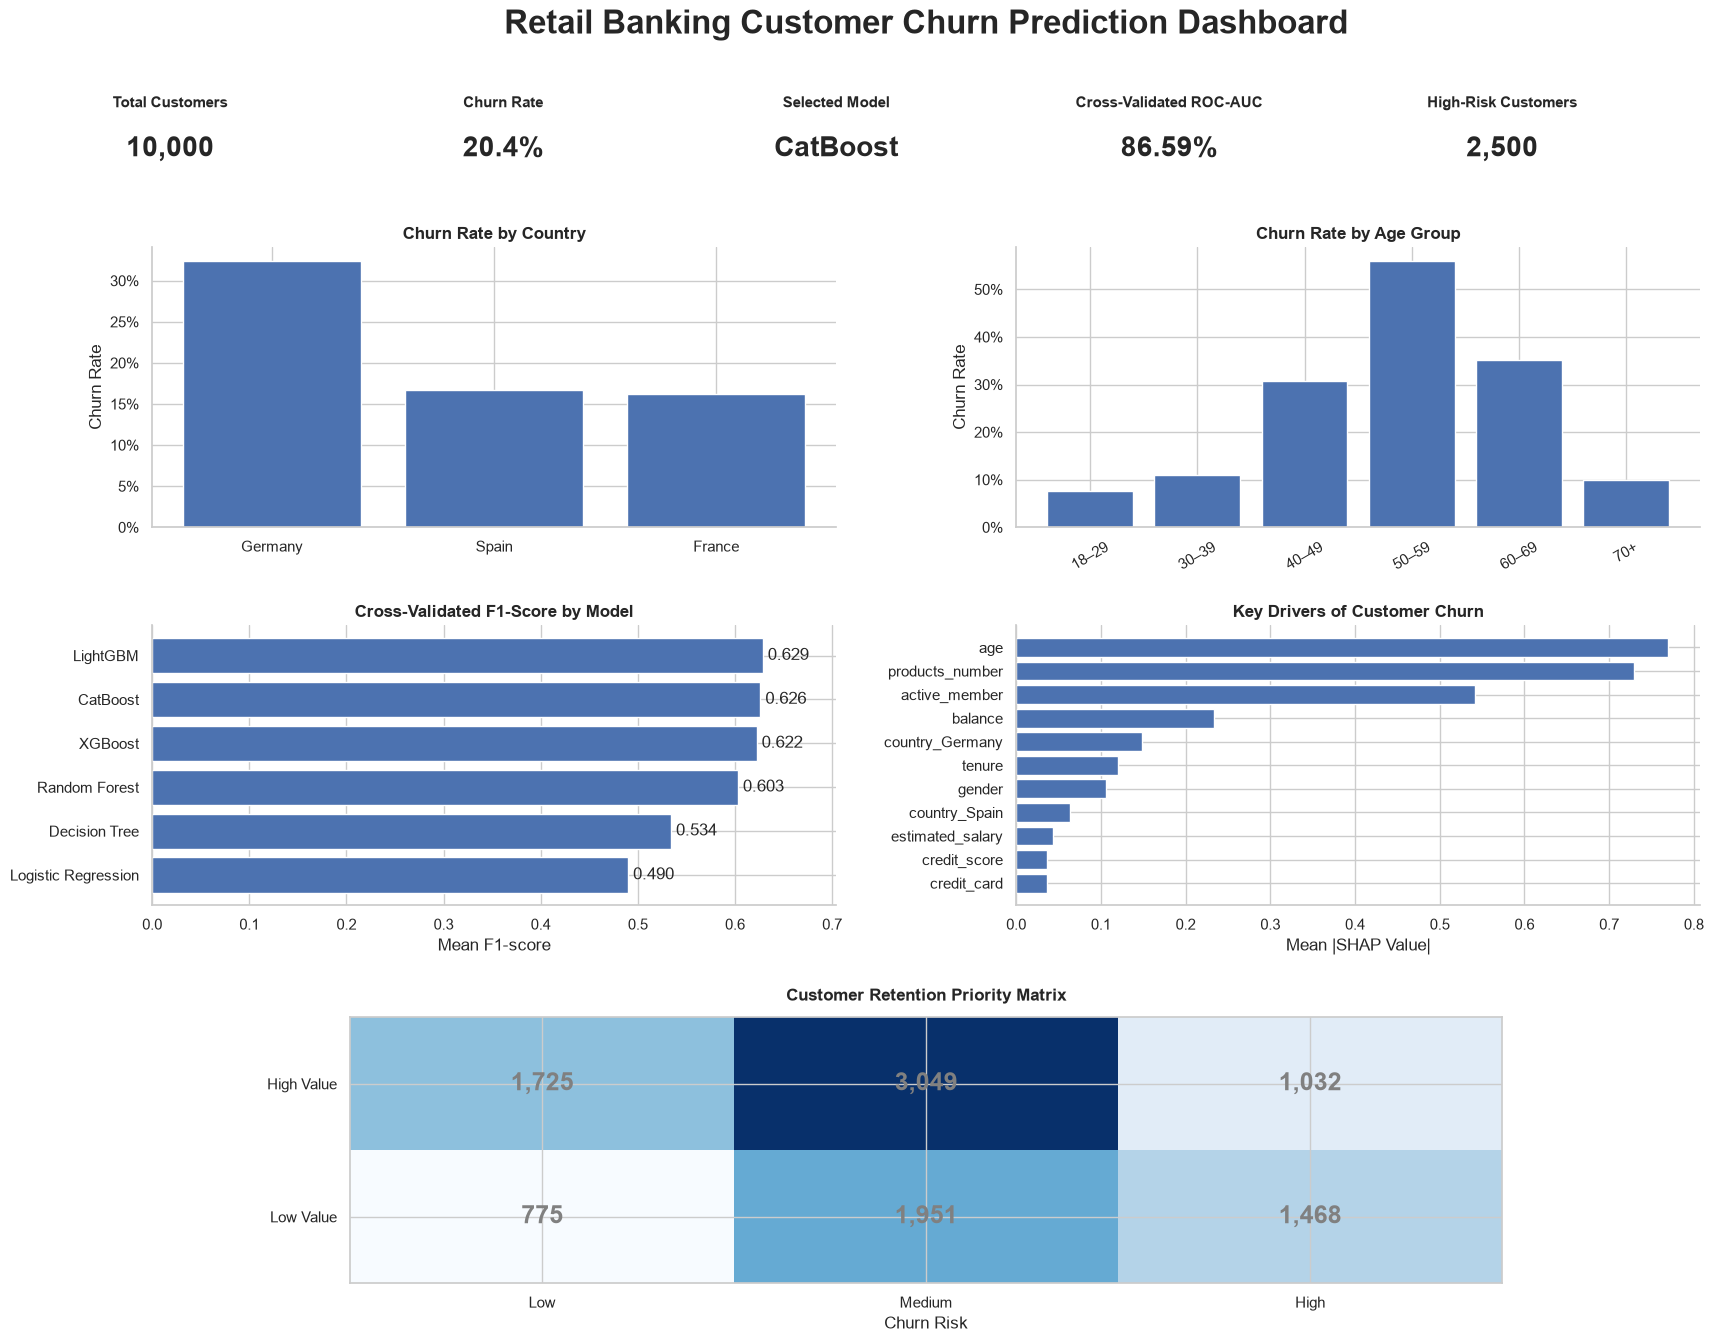

In [482]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 14))

fig.suptitle(
    "Retail Banking Customer Churn Prediction Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# --------------------------------------------------
# KPI CARDS
# --------------------------------------------------

kpi_titles = [
    "Total Customers",
    "Churn Rate",
    "Selected Model",
    "Cross-Validated ROC-AUC",
    "High-Risk Customers"
]

kpi_values = [
    f"{total_customers:,}",
    f"{churn_rate:.1%}",
    best_model,
    f"{best_roc_auc:.2%}",
    f"{high_risk_customers:,}"
]

positions = [0.08, 0.265, 0.45, 0.635, 0.82]

for x, title, value in zip(
    positions,
    kpi_titles,
    kpi_values
):
    fig.text(
        x,
        0.91,
        title,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    fig.text(
        x,
        0.875,
        value,
        ha="center",
        fontsize=20,
        fontweight="bold"
    )

# --------------------------------------------------
# CHURN BY COUNTRY
# --------------------------------------------------

ax1 = fig.add_axes([0.07, 0.61, 0.38, 0.20])

ax1.bar(
    country_churn.index,
    country_churn.values
)

ax1.set_title(
    "Churn Rate by Country",
    fontweight="bold"
)

ax1.set_ylabel("Churn Rate")

ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --------------------------------------------------
# CHURN BY AGE GROUP
# --------------------------------------------------

ax2 = fig.add_axes([0.55, 0.61, 0.38, 0.20])

ax2.bar(
    age_churn.index.astype(str),
    age_churn.values
)

ax2.set_title(
    "Churn Rate by Age Group",
    fontweight="bold"
)

ax2.set_ylabel("Churn Rate")

ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

ax2.tick_params(
    axis="x",
    rotation=30
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# --------------------------------------------------
# MODEL COMPARISON
# --------------------------------------------------

ax3 = fig.add_axes([0.07, 0.34, 0.38, 0.20])

ax3.barh(
    cv_f1.index,
    cv_f1.values
)

ax3.set_title(
    "Cross-Validated F1-Score by Model",
    fontweight="bold"
)

ax3.set_xlabel("Mean F1-score")

ax3.set_xlim(
    0,
    max(cv_f1.values) * 1.12
)

for i, value in enumerate(cv_f1.values):
    ax3.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center"
    )

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# --------------------------------------------------
# SHAP FEATURE IMPORTANCE
# --------------------------------------------------

ax4 = fig.add_axes([0.55, 0.34, 0.38, 0.20])

ax4.barh(
    shap_dashboard["Feature"],
    shap_dashboard["Mean_Absolute_SHAP"]
)

ax4.set_title(
    "Key Drivers of Customer Churn",
    fontweight="bold"
)

ax4.set_xlabel("Mean |SHAP Value|")

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

# --------------------------------------------------
# RETENTION MATRIX
# --------------------------------------------------

ax5 = fig.add_axes([0.18, 0.07, 0.64, 0.19])

matrix_values = retention_dashboard.values

image = ax5.imshow(
    matrix_values,
    aspect="auto"
)

ax5.set_title(
    "Customer Retention Priority Matrix",
    fontweight="bold",
    pad=12
)

ax5.set_xticks(
    range(len(retention_dashboard.columns))
)

ax5.set_xticklabels(
    retention_dashboard.columns
)

ax5.set_yticks(
    range(len(retention_dashboard.index))
)

ax5.set_yticklabels(
    [
        f"{value} Value"
        for value in retention_dashboard.index
    ]
)

ax5.set_xlabel("Churn Risk")


for i in range(matrix_values.shape[0]):
    for j in range(matrix_values.shape[1]):
                


        ax5.text(
            j,
            i,
            f"{matrix_values[i, j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="grey"

        )

image = ax5.imshow(
    matrix_values,
    cmap="Blues",
    aspect="auto"
)


plt.savefig(
    "customer_churn_executive_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()